# Final Project for Chem 277A #

### Research Question ###
Can we (a) identify natural products that share key binding-relevant substructures of rapamycin and (b) evaluate whether they exhibit strong binding affinity to FKBP12, a protein that forms a complex with rapamycin to inhibit mTORC1, a key driver of aging? 


### Methods ###
This project integrates chemical structure features with functional binding affinity to identify structure-function relationships. The FKBP-12-rapamycin complex was obtained from the Protein Data Bank and processed with RDKit to extract the rapamycin binding fragment and characterize the FKBP12 binding pocket.  Candidate molecules were sourced from the COCONUT natural products database (~740K compounds) and filtered based on structural features. Morgan fingerprints were used to characterize the rapamycin binding fragment and candidate molecules, with similarity between them measured using Tanimoto and Tversky metrics.  Principal component analysis (PCA) and K-Means clustering were applied to the chemical feature space of the candidate molecules. AutoDock Vina was used to estimate binding affinity of candidate molecules with the FKBP12 binding pocket.

### Analysis Choices ###
Analysis choices were broken down in terms of the major components involved in this project, which are summarized below. 

#### Data Processing / Harmonization:
##### PDB database FKBP12-Rapamycin complex sourced (CIF file)
Data processing and harmonization for the FKBP12-Rapamycing complex included using the CIF file from the PDB database, identifying the rapamycin atoms, inspecting their structure, and extracting the associated atoms. The identified atoms from this rapamycin binding region were then converted to an RDKit molecular object, with pharmacophore associated atoms mapped to RDKit indices. Finally this extracted rapamycin binding fragment was satizied with RDKit to ensure molecular integrity was maintained. 

##### Coconut database of natural products sourced (CSV file)
Data processing and harmonization for the candidate molecules from the Coconut database was performed on the full database CSV file, where each molecule's SMILES data was converted to a corresponding dataset of RDKit molecule objects. Additional features and COCONUT dataset parametes were added to the RDKit dataset.  This was then prefiltered to remove data with missing key features such as mw, hba/hbd, TPSA, logP, rings, aromatic rings, and amides. It was further prefiltered to exclude aotms with parameters which are not associated with valid drug targets such as being too small or large. Invalid and duplicate SMILES entries were also removed. This resulted in ~97K candidate molecules. 

##### Morgan Fingerprints and Similarity Scoring:
Morgan fingerprints were calculated for rapamycin binding fragment and the candidate molecules, using a bit length of 2048, and testing radius 1 and radius 2 since each has associated tradeoffs, which could be evaluated during subsequent processing steps. Similarity scoring was performed between the rapamycin binding region template and all candidate molecules, using both Tanimoto and Tversky methods. Tversky was included because it has two hyperparameters which control whether similarity scoring penalizes extra structural features present, or penalizing absence of desired structural features. We tested two settings of these hyperparameters. The first was referred to as 'symmetric', meaning we penalized both attributes equally. The second was referred to a 'feature-focused' which only penalized absence of desired features and minimized the penalty for superfluous features. This was done since candidate molecules had a broad diversity of size, and only the binding region attributes were desired, so superfluous attributes were deemed acceptable. Tversky consistently scored higher similarity scores than Tanimoto, but since we only sought a similarity metric which stratified results by similarity, the scale difference was not important. We measure the extent they both stratified candidate molecules similarly by calculating the correlation between Tanimoto and Tversky methods for both the entire dataset and for those with the best binding affinity.  

##### Feature Clustering
Feature clustering connected the similarity scoring to the features present in each candidate molecule (mw, hba/hbd, Rings, Aromatic rings, TPSA, logP). PCA was used for displaying results, with K-Means clustering used to identify patterns among the features being associated with binding affinity. A silhouette plot was produced to help identify the optimal number of clusters (k=2 clusters), but a secondary number (k=4 clusters) was also examined to determine if subclusters may exist. 

##### Docking
Docking measurements were made by first extract the FKBP12 binding site atoms and convert them to an RDKit object. We validated the docking box by size, but alternative sizes could and should also be considered in future work. 1000 top binding candidate ligands were prepared to address anomolies from real chemistry associated with x-ray crystallography determination of candidate molecule structures. This included removing water and adding hydrogen atoms. 971 of them survived this process, which were then coverted back to SMILES, then to PDB and PDBQT files using Babel. AutoDoc Vina was used to measure candidate molecules binding affinity with the FKBP12 binding pocket. Certain hyperparameters with Vina had to be adjusted (exhaustiveness=4, n_poses=5) in order to process all 971 molecules within a reasonable time with a laptop computer. Additional hyperparameter choices should be explored in future work. 

##### Relate Binding Affinity to Model
The relationship between similarity scoring and binding affinity was analyzed by plotting Vina scores against different number of candidate molecules ranked by similarity scoring. The relationhip between features and binding was also incorporated on this plot by separating the two primary clusters from K-Means along the PC1 dimension on the graph, indicating which how each of the two primary clusters each tracked with binding affinity and similarity scoring. A box plot further looked at key features split between the two primary clusters, one cluster having higher bonding affinity than the other. 

### Results ### 


### Conclusions and Future Work ###

### Study Limitations and Future Work ###


### References ###
1. Khazanov NA, Carlson HA. Exploring the composition of protein-ligand binding sites on a large scale. PLoS Comput Biol. 2013;9(11):e1003321. doi: 10.1371/journal.pcbi.1003321. Epub 2013 Nov 21. PMID: 24277997; PMCID: PMC3836696.



## Detailed Workflow ##

Phase 0: Exploratory Data Analysis
A. Load COCONUT Database (Full version)
B. Verify RDKit converts SMILES string into a molecule object
C. Quantify extent SMILES data is missing
D. Calculate molecular weight and show distribution from SMILES using RDKit
E. Rapamycin SMILES Data as sanity check


Phase 1: Characterize Rapamycin Binding Fragment, Candidate Molecules, Morgan Fingerprints and Similary Scoring
A. Load FKBP12-rapamycin structure (CIF file)
B. Inspect structure
C. Identify contact atoms
  1. The Protein chain (A), Rapamycin ligand (RAP), Residue ID (108)
  2. Identify rapaymcin atoms contacting FKBP12 (defined binding region)
D. Build interaction map (using 3.5 angstrom distance to start)
E. Classify interactions
  1. H-bond donor or acceptor (HBD, HBA)
  2. Hydrophobic contact (non-polar packing)
  3. Polar contacts
  4. Aromatic interactions (pi - pi stacking) (OPTIONAL LATER)
F. Extract rapamycin pharmacophore atoms
G. Load full structure in RDKit (PDB file) (NOT NECESSARY)
H. Identify rapamycin atoms in RDKit
I. Map pharmacophore atoms to RDKit indices
J. Extract binding fragment from rapamycin binding region
K. Sanitize fragment
L. Load Coconut dataset
M. Convert SMILES to RDKit molecules (with pickle cache)
N. Prefilter Coconut dataset molecules (Molecular weight, HBD/HBA, size)
  - Run diagnostic to determine breakdown of filter parameters
  - Filter dataset to include reasonable drug-like candidates
O. Define fingerprint function
P. Calculate rapamycin binding fragment morgan fingerprint
Q. Compute candidate molecules morgan fingerprint and similarity scores 
  - Use Tanimoto and Tversky
  - Benchmark small batch (time)
  - Batch process
  - Convert to dataframe
R. Rank candidates
S. Perform local fragment similarity
  - atom-centered Morgan environments
  - scanning entire molecule
  - taking the maximum similarity
T. Compare top hits based on Tanimoto and Tversky
  - Scatter plot
  - Correlation
  - Interpretation
  - Top hit overlap
  - Rank correlation
  - Identify disagreement molecules
  - Histogram comparison


Phase 2: Local Similarity Analysis
A. Select candidates (e.g. top 5000?)
B. Create local similarity function part I (using Tanimoto and Tversky, r1 and r2)
  - Looking at radius 1 and radius 2 morgan fingerprints
  - Checking for 
C. Compute local scores (using Tanimoto and Tversky)
D. Analyze results


Phase 3: Unsupervised Clustering on Features (w/o Similarity Score)
A. Input data
B. Feature Extraction
C. Build feature dataframe
D. Run feature extraction
E. Define feature columns
F. Apply feature scaling
G. PCA computation
H. K-Means evaluation
  - Run K-Means function
  - Evaluate K-Means function
  - Run K-Means evaluation 
  - Plot results
  - Analyze results
I. GMM evaluation (ADD LATER)


ADD BELOW TO Phase 3: Dimensionality Reduction and Visualization
A. Scaling features defined
B. PCA variance analysis
  - Plot variance (individual PCA components and cumulative)
  - Select number of PCA components
  - PCA reduction

D. Clustering via K-Means
  - Cluster summary - K-Means
  - Heatmap - K-Means
E. Clustering via GMM
  - Cluster summary - GMM
  - Heatmap - GMM
F. Visualization
  - PCA with K-Means
  - PCA with GMM ?
G. Cluster interpretation
H. Sensitivity analysis of top candidates
I. UMAP (OPEN ITEM)

Phase 4: Supervised regression (predicting Similarity from Features)
(ADD WORKFLOW STEP)

Phase 5: Docking Binding Affinity (using AutoDoc Vina) 
A. Lock candidate selection (from sensitivity analysis)
B. Map similarity
C. Select docking candidates
D. Extract real FKBP12 binding site (from PDB)
E. Validate docking box (numerical + visual)
F. Prepare ligands
G. Prepare receptor
H. Run docking
I. Analyze results (tie back to PCA clusters)

Phase 6: Unsupervised Clustering on Features and Similarity Score


Phase 7: Supervised regression (predicting Binding Affinity from Features + Similarity)
A. (MAYBE) Naive Bayes (use docked molecules to predict which of the non-dock molecules are likely high affinity binders without docking them) 
  - Label Hit = Vina <= -8.0 (or something)
  - Train GaussianNB on features
  - Predict hit probability for un-docked candidate molecules
   - Rank by P(hit)
   - Select top 100 - 1000? for docking
B. Linear regression 
C. L1/L2 regularization
D.


### Setup and installation

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import namedtuple

from rdkit import Chem
from rdkit.Chem import Descriptors, rdmolops, AllChem, Crippen, rdMolDescriptors, DataStructs, Fragments, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import silhouette_score, silhouette_samples, accuracy_score, roc_auc_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import warnings

from tqdm import tqdm

from Bio.PDB import NeighborSearch
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB import PDBParser



from meeko import MoleculePreparation

# from vina import Vina

import pickle

import time

import os
import subprocess

import shap
import umap



/Users/sibhisak/Downloads/CHEM277A/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Suppress deprecation warnings
# Hide Python warnings (Deprecation/Future/User/Runtime)
# warnings.filterwarnings("ignore")

# Optional: hide specific warning categories only
warnings.filterwarnings("ignore", category=DeprecationWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

RDLogger.DisableLog("rdApp.warning")

### Phase 0: Exploratory Data Analysis

In [5]:
# P0.A Load COCONUT Database (Full version)
# Set SKIP_COCONUT_LOADING = True if it was previously loaded and/or not needed
# because a subsequent RDKit version was created and saved
SKIP_COCONUT_LOADING = True

if not SKIP_COCONUT_LOADING:
    df = pd.read_csv("coconut_csv-04-2026.csv")  # Loaded as Pandas dataframe 'df'

    print(df.columns)
    print(df.head())

In [6]:
# P0.B Verify RDKit converts SMILES string into a molecule object

if not SKIP_COCONUT_LOADING:
    valid_count = 0

    for smi in df['canonical_smiles'].head(100):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            valid_count += 1

    print(f"Valid molecules: {valid_count}/100")

In [7]:
# P0.C Quantify extent SMILES data is missing

if not SKIP_COCONUT_LOADING:
    # Total rows
    total = len(df)

    # Missing SMILES
    missing = df['canonical_smiles'].isna().sum()

    # Invalid SMILES
    invalid = 0

    for smi in tqdm(df['canonical_smiles'].dropna()):
        if Chem.MolFromSmiles(smi) is None:
            invalid += 1

    valid = total - missing - invalid

    print(f"Total molecules: {total}")
    print(f"Missing SMILES: {missing}")
    print(f"Invalid SMILES: {invalid}")
    print(f"Valid molecules: {valid}")
    print(f"% Valid: {valid / total * 100:.2f}%")

In [8]:
# P0.D Calculate molecular weight and show distribution from SMILES using RDKit
if not SKIP_COCONUT_LOADING:
    def safe_mw(smi):
        """
        Parse SMILES string into an RDKit molecule 'mol' and calculate average molecular weight
        Returns None if SMILES is invalid.
        """
        # Turn 
        mol = Chem.MolFromSmiles(smi)       
        if mol is not None:
            return Descriptors.MolWt(mol)   # Compute average molecular weight (from all isotopes)
        return None

    print("Computing molecular weights (safe)...")

    # Compute MW safely and add to Pandas dataframe 'df' as new column 'MW'
    df['MW'] = df['canonical_smiles'].apply(safe_mw)

    # Count invalid molecules
    invalid_count = df['MW'].isna().sum()
    print(f"Invalid molecules (failed parsing): {invalid_count}")

    # Drop invalid rows
    df = df.dropna(subset=['MW'])

    print(f"Dataset size after cleaning: {len(df)}")

    # Summary statistics
    print("\nMolecular Weight Summary:")
    print(df['MW'].describe())

    # Histogram
    plt.hist(df['MW'], bins=50, range=(0, 2000))
    plt.xlabel("Molecular Weight (Da)")
    plt.ylabel("Count")
    plt.title("Distribution of Molecular Weights (<= 2000 Da shown)")
    plt.show()


### Obtain Rapamycin SMILES structure (MAY NOT BE REQUIRED)

1. Pubchem: https://pubchem.ncbi.nlm.nih.gov/compound/5284616
2. Download SDF file
3. Rename as rapamycin.sdf in notebook folder
4. Read in molecule and verify number of atoms (65) and MW (~914 Da)

In [9]:
# NOT NEEDED BUT INCLUDED AS SANITY CHECK
# P0.E Rapamycin SMILES Data as sanity check

supplier = Chem.SDMolSupplier("rapamycin.sdf")
rapa_mol = supplier[0]
assert rapa_mol is not None
print("Atoms:", rapa_mol.GetNumAtoms())
print("MolWt:", Descriptors.MolWt(rapa_mol))


Atoms: 65
MolWt: 914.1869999999998


### Phase 1: Characterize Rapamycin Binding Fragment, Candidate Molecules, Morgan Fingerprints and Similary Scoring

In [10]:
# P1.A Load FKBP12-rapamycin structure (CIF file)
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("FKBP12_RAPA", "1FKB.cif")

Instructions for above:
  1. Use the RCSB Protein Data Bank, https://www.rcsb.org/
  2. Search FKBP12 rapamycin 1FKB structure (https://www.rcsb.org/structure/1FKB)
  3. Download the 1FKB.cif file
  3. Download and unzip the 'Biological Assembly 1 (PDB - gz)' file
  4. Verify loaded in to RDKit

In [11]:
# P1.B Inspect structure
model = structure[0]

print("Structure loaded:", structure)

print("\nChains:")
for chain in model:
    print("Chain ID:", chain.id)

print("\nLigands:")
for chain in model:
    for residue in chain:
        if residue.id[0] != " ":
            print(
                "Chain:", chain.id,
                "Ligand:", residue.resname,
                "Residue ID:", residue.id
            )

Structure loaded: <Structure id=FKBP12_RAPA>

Chains:
Chain ID: A

Ligands:
Chain: A Ligand: RAP Residue ID: ('H_RAP', 108, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 109, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 110, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 111, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 112, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 113, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 114, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 115, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 116, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 117, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 118, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 119, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 120, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 121, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 122, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 123, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 124, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 125, ' ')
Chain: A Ligand: HOH Residue ID: ('W',

In [12]:
# P1.C Identify contact atoms
# Using 3.5 Angstrom distance from rapamycin contact atoms for FKBP12 'neighbors'
atoms = list(structure.get_atoms())
ns = NeighborSearch(atoms)

contact_atoms = set()

for chain in model:
    for residue in chain:
        if residue.resname == "RAP":
            for lig_atom in residue:
                neighbors = ns.search(lig_atom.coord, 3.5)
                for prot_atom in neighbors:
                    if (
                        prot_atom.parent.resname != "RAP"
                        and prot_atom.parent.resname != "HOH"
                    ):
                        contact_atoms.add(lig_atom)
                        break

print("Contact atoms:", len(contact_atoms))

Contact atoms: 20


* Note on above: This distance determines which FKBP12 atoms will be included away from the binding site atoms
  - 4 angstroms from rapamycin bindinging atoms (returned 39 atoms)
  - 3.5 angstroms (returned 20 atoms)
  - 3 angstroms (returned 9 atoms)
Why 3.5 Å?
  - This distance ensures the interaction map (below) captures all hydrogen bonds and the closes hydrophobic contacts without including distant atoms that aren't contributing to the binding energy
  - "In summary, 3.5 Å is a widely accepted benchmark because it encompasses almost all biochemically relevant polar interactions while excluding the noise from more distant, non-specific contacts."
    - Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC3836696/
    - Khazanov NA, Carlson HA. Exploring the composition of protein-ligand binding sites on a large scale. PLoS Comput Biol. 2013;9(11):e1003321. doi: 10.1371/journal.pcbi.1003321. Epub 2013 Nov 21. PMID: 24277997; PMCID: PMC3836696.

In [13]:
# P1.D Build interaction map (3.5 Angstrom)
# Define interaction map structure
Interaction = namedtuple('Interaction', [
    'lig_serial',
    'lig_atom_name',
    'prot_res_name',
    'prot_res_id',
    'prot_atom_name'
    ])

interaction_map = []    # List version for use later

# Iterate over the rapamycin ligand 'contact_atoms'
for lig_atom in contact_atoms:   
    
    # Find all FKBP12 and rapamycin atoms 'neighbors' within the search distance (3.5 angstrom)
    neighbors = ns.search(lig_atom.coord, 3.5) 

    for prot_atom in neighbors:
        if (
            prot_atom.parent.resname != "RAP"       # Ignore rapamycin "RAP" atoms in search distance
            and prot_atom.parent.resname != "HOH"   # Ignore water molecules in the search distance
        ):      
            entry = Interaction(
                    lig_serial = lig_atom.serial_number,      # Rapamycin ligand serial number
                    lig_atom_name = lig_atom.name,            # Rapamycin ligand atom
                    prot_res_name = prot_atom.parent.resname, # FKBP12 protein residue name
                    prot_res_id = prot_atom.parent.id[1],     # FKBP12 protein residue ID   
                    prot_atom_name = prot_atom.name           # FKBP12 protein atom name
                )
            interaction_map.append(entry)                     # Update  interaction_map list

print("Total interactions:", len(interaction_map))

Total interactions: 40


* The interaction map list above documents every atomic "handshake" between rapamycin and the FKBP12 protein. It indicates which specific rapamycin atom is touching which specific atom on FKBP12. This will be used to classify the interactions in the subsequent cell (e.g. hydrophobic or polar residues)

In [14]:
# P1.E Classify interactions
hydrophobic_residues = {
    "PHE","TRP","LEU","ILE","VAL","MET","ALA","PRO"
}

polar_residues = {
    "SER","THR","ASN","GLN","TYR","HIS"
}

hbond_interactions = []
hydrophobic_interactions = []
polar_interactions = []

for entry in interaction_map:

    lig_serial, lig_atom, prot_res, prot_res_id, prot_atom = entry

    if lig_atom[0] in ["O","N"] and prot_atom[0] in ["O","N"]:
        hbond_interactions.append(entry)

    elif lig_atom[0] == "C" and prot_res in hydrophobic_residues:
        hydrophobic_interactions.append(entry)

    elif lig_atom[0] in ["O","N"] and prot_res in polar_residues:
        polar_interactions.append(entry)

print("HBonds:", len(hbond_interactions))
print("Hydrophobic:", len(hydrophobic_interactions))
print("Polar:", len(polar_interactions))

HBonds: 8
Hydrophobic: 1
Polar: 3


In [15]:
# P1.F Extract rapamycin pharmacophore atoms
pharmacophore_atoms = set()

for group in [hbond_interactions, hydrophobic_interactions, polar_interactions]:
    for entry in group:
        lig_serial = entry[0]

        for atom in contact_atoms:
            if atom.serial_number == lig_serial:
                pharmacophore_atoms.add(atom)

print("Pharmacophore atoms:", len(pharmacophore_atoms))


Pharmacophore atoms: 10


In [16]:
# P1.G Load full structure in RDKit (PDB file)
# 1. Go to https://www.rcsb.org
# 2. Search for 1FKB
# 3. Click the result 'FKBP12–rapamycin complex'
# 4. Download file as PDB format
# 5. Save as 1FKB.pdb
# 6. Add to working directory

full_structure = Chem.MolFromPDBFile(
    "1FKB.pdb",
    removeHs=False
)

print("Loaded:", full_structure is not None)
print("Atoms:", full_structure.GetNumAtoms())

Loaded: True
Atoms: 1222


In [17]:
# P1.H Identify rapamycin atoms in RDKit
rapa_atom_indices = []

for atom in full_structure.GetAtoms():
    info = atom.GetPDBResidueInfo()

    if info is not None:
        if info.GetResidueName().strip() == "RAP":
            rapa_atom_indices.append(atom.GetIdx())

print("Rapamycin atoms:", len(rapa_atom_indices))

Rapamycin atoms: 68


In [18]:
# P1.I Map pharmacophore atoms to RDKit indices
rdkit_pharmacophore_indices = []

for atom in full_structure.GetAtoms():
    info = atom.GetPDBResidueInfo()
    if info is None:
        continue
    if info.GetResidueName().strip() != "RAP":
        continue
    rdkit_name = info.GetName().strip()
    for bio_atom in pharmacophore_atoms:
        if bio_atom.name.strip() == rdkit_name:
            rdkit_pharmacophore_indices.append(atom.GetIdx())
            break

print("Mapped pharmacophore atoms:", len(rdkit_pharmacophore_indices))

Mapped pharmacophore atoms: 10


In [19]:
# P1.J Extract binding fragment from rapamycin binding region
binding_fragment = Chem.PathToSubmol(
    full_structure,
    rdkit_pharmacophore_indices
)

# Sanity checks
print("Fragment atoms:", binding_fragment.GetNumAtoms())
from rdkit import Chem

print(Chem.MolToSmiles(binding_fragment))

Fragment atoms: 15
CC.CC.CC=O.CCC.NCC(N)=O


In [20]:
# P1.K Sanitize fragment
# RDKit validates and updates a molecule's structure by calculating aromaticity, checking valencies, and setting 
# hybridization. It ensures the molecule is chemically valid.

rdmolops.SanitizeMol(binding_fragment)

rdkit.Chem.rdmolops.SanitizeFlags.SANITIZE_NONE

In [21]:
# P1.L Load Coconut Dataset
SKIP_COCONUT_LOADING = True

if not SKIP_COCONUT_LOADING:

    # Load dataset (make sure file is in same directory)
    coconut = pd.read_csv("coconut_csv-04-2026.csv")

    # Keep only SMILES, name, identifier
    #coconut = coconut[["canonical_smiles"]].dropna()
    coconut = coconut[[
        "canonical_smiles",
        "name",
        "identifier"
    ]].dropna(subset=["canonical_smiles"])


    # Rename column for consistency
    coconut.rename(columns={"canonical_smiles": "smiles"}, inplace=True)

    print("Initial dataset size:", len(coconut))
    print(coconut.columns)
    print(coconut.head())

In [22]:
# P1.M Convert SMILES to RDKit molecules (with optional skip)

PICKLE_PATH = "rdkit_coconut_molecules.pkl"
REBUILD_MOLECULES = False   # True = recompute from SMILES and overwrite pickle
                            # False = load from pickle if it exists
SKIP_MOLECULES_LOADING = True  # True = skip loading/building molecules in this cell
                               #       (use filtered cache in next cell)
                               # False = load rebuilt molecules 

if SKIP_MOLECULES_LOADING:
    print("Skipping molecule cache load/build in this cell.")
    print("Filtered cache can be loaded in the next prefilter cell.")
    molecules = None
elif not REBUILD_MOLECULES:
    print(f"Loading cached molecules from {PICKLE_PATH} ...")
    with open(PICKLE_PATH, "rb") as f:
        molecules = pickle.load(f)
    print(f"Loaded {len(molecules)} molecules from cache.")
else:
    print("Converting SMILES to RDKit molecules...")
    molecules = []
    invalid_mols = 0

    for _, row in tqdm(coconut.iterrows(), total=len(coconut)):
        smi = row["smiles"]
        mol = Chem.MolFromSmiles(smi)

        if mol is not None:
            molecules.append((smi, mol, row["name"], row["identifier"]))
        else:
            invalid_mols += 1

    print("Valid molecules:", len(molecules))
    print(f"Invalid SMILES skipped: {invalid_mols}")

    print(f"Saving cache to {PICKLE_PATH} ...")

    # Save file with HIGHEST_PROTOCOL (most efficient/compact binary form)
    with open(PICKLE_PATH, "wb") as f:
        pickle.dump(molecules, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("Cache saved.")

Skipping molecule cache load/build in this cell.
Filtered cache can be loaded in the next prefilter cell.


In [23]:
# P1.N Prefilter Coconut dataset molecules (cont.)
# Adjust filtering based on filtering counts from above (226,367 molecules)

PICKLE_PATH_FILTERED = "rdkit_coconut_molecules_filtered.pkl"
REBUILD_MOLECULES_FILTERED = False   # True = recompute from RDKit molecules and overwrite pickle
                                     # False = load from pickle if it exists

FILTERS = {
    "mw_min": 350,
    "mw_max": 700,
    "hba_min": 3,
    "hba_max": 8,
    "hbd_min": 1,
    "hbd_max": 4,
    "logp_min": 2,
    "logp_max": 5,
    "rings_min": 2,
    "rings_max": 5,
    "tpsa_max": 150
}

if not REBUILD_MOLECULES_FILTERED and os.path.exists(PICKLE_PATH_FILTERED):
    print(f"Loading cached filtered molecules from {PICKLE_PATH_FILTERED} ...")
    with open(PICKLE_PATH_FILTERED, "rb") as f:
        filtered = pickle.load(f)
    print(f"Loaded {len(filtered)} filtered molecules from cache.")
else:
    if molecules is None:
        raise ValueError(
            "molecules is None. Set SKIP_MOLECULES_LOADING = False in the previous cell "
            "or set REBUILD_MOLECULES_FILTERED = False with an existing filtered pickle."
        )

    print("Running prefilter...")
    filtered = []

    #for smi, mol in molecules:
    for smi, mol, name, cid in tqdm(molecules, total=len(molecules)):
        try:
            mw = Descriptors.MolWt(mol)
            hba = Descriptors.NumHAcceptors(mol)
            hbd = Descriptors.NumHDonors(mol)
            logp = Crippen.MolLogP(mol)
            rings = Descriptors.RingCount(mol)
            tpsa = Descriptors.TPSA(mol)

            # Apply filters
            if not (FILTERS["mw_min"] < mw < FILTERS["mw_max"]):
                continue
            if not (FILTERS["hba_min"] <= hba <= FILTERS["hba_max"]):
                continue
            if not (FILTERS["hbd_min"] <= hbd <= FILTERS["hbd_max"]):
                continue
            if not (FILTERS["logp_min"] < logp < FILTERS["logp_max"]):
                continue
            if not (FILTERS["rings_min"] <= rings <= FILTERS["rings_max"]):
                continue
            if tpsa > FILTERS["tpsa_max"]:
                continue

            #filtered.append((smi, mol))
            filtered.append((smi, mol, name, cid))
        except:
            continue

    print(f"Saving filtered cache to {PICKLE_PATH_FILTERED} ...")
    with open(PICKLE_PATH_FILTERED, "wb") as f:
        pickle.dump(filtered, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("Cache saved.")

print("Filtered molecules:", len(filtered))

Loading cached filtered molecules from rdkit_coconut_molecules_filtered.pkl ...
Loaded 96682 filtered molecules from cache.
Filtered molecules: 96682


* Note on filtering: Descriptor availability was used as a filtering criterion, which may bias the dataset toward well-characterized molecules. Future work could recompute all descriptors directly from SMILES molecular structures to avoid exclusion due to missing values and expand coverage of chemical space.

Start: ~738K molecules
Filter on properties (mw, hba, hbd, logp, rings, tpsa): ~97K molecules pass

These features are derived, not measured, so cannot be imputed. These are drug-like / rapamycin-like molecule attributes
 - MW → from structure
 - HBA/HBD → from structure
 - TPSA → from structure
 - logP → computed
 - rings → computed

In [24]:
# P1.O Create morgan fingerprint function

# Define fingerprint function
def get_fp_from_mol(mol, radius):
    return AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        2048,
        useFeatures=True 
    )


In [25]:
# P1.P Calculate rapamycin binding fragment morgan fingerprint
# Precompute query fingerprints (using radius = 1 and 2) from rapamycin binding fragement
from rdkit.Chem import AllChem

# Morgan fingerprint from rapamycin binding fragment (radius=1 and 2)
binding_fp_r1 = get_fp_from_mol(binding_fragment, 1)    
binding_fp_r2 = get_fp_from_mol(binding_fragment, 2)

print("Binding FP bits:",
      binding_fp_r1.GetNumOnBits(),
      binding_fp_r2.GetNumOnBits())

Binding FP bits: 12 13


In [26]:
# P1.Q Compute candidate molecule morgan fingerprint and similarity scores 
# Benchmark small batch based (time) (using radius = 2)

test_batch = filtered[:1000]
start = time.time()

for smi, mol, name, cid in test_batch:
    fp = get_fp_from_mol(mol, 2)

end = time.time()

print("Time for 1000 molecules:", end - start, "seconds")

Time for 1000 molecules: 0.16560721397399902 seconds


In [27]:
# P1.Q Compute candidate molecule morgan fingerprint and similarity scores
from rdkit.Chem import DataStructs

batch_size = 2000
results = []

for i in range(0, len(filtered), batch_size):

    batch = filtered[i:i+batch_size]

    for smi, mol, name, cid in batch:
        try:
            fp_r1 = get_fp_from_mol(mol, 1)
            fp_r2 = get_fp_from_mol(mol, 2)

            # Tanimoto
            tan_r1 = DataStructs.TanimotoSimilarity(binding_fp_r1, fp_r1)
            tan_r2 = DataStructs.TanimotoSimilarity(binding_fp_r2, fp_r2)
            sim_tanimoto = max(tan_r1, tan_r2)

            # Tversky (symmetric (alpha=beta=0.5)
            alpha = 0.5
            beta = 0.5
            tv_sym_r1 = DataStructs.TverskySimilarity(
                binding_fp_r1, fp_r1, alpha, beta
            )
            tv_sym_r2 = DataStructs.TverskySimilarity(
                binding_fp_r2, fp_r2, alpha, beta
            )
            sim_tv_sym = max(tv_sym_r1, tv_sym_r2)

            # Tversk (fragment-focused (alpha=0.1, beta=0.9)) 
            alpha = 0.1
            beta = 0.9
            tv_frag_r1 = DataStructs.TverskySimilarity(
                binding_fp_r1, fp_r1, alpha, beta
            )
            tv_frag_r2 = DataStructs.TverskySimilarity(
                binding_fp_r2, fp_r2, alpha, beta
            )
            sim_tv_frag = max(tv_frag_r1, tv_frag_r2)

            results.append({
                "smiles": smi,
                "name": name,
                "coconut_id": cid,
                "sim_tanimoto": sim_tanimoto,
                "sim_r1_tan": tan_r1,
                "sim_r2_tan": tan_r2,
                "sim_tv_sym": sim_tv_sym,
                "sim_r1_tv_sym": tv_sym_r1,
                "sim_r2_tv_sym": tv_sym_r2,
                "sim_tv_frag": sim_tv_frag,
                "sim_r1_tv_frag": tv_frag_r1,
                "sim_r2_tv_frag": tv_frag_r2
            })


        except:
            continue

    print(f"Processed {i + len(batch)} / {len(filtered)}")


Processed 2000 / 96682
Processed 4000 / 96682
Processed 6000 / 96682
Processed 8000 / 96682
Processed 10000 / 96682
Processed 12000 / 96682
Processed 14000 / 96682
Processed 16000 / 96682
Processed 18000 / 96682
Processed 20000 / 96682
Processed 22000 / 96682
Processed 24000 / 96682
Processed 26000 / 96682
Processed 28000 / 96682
Processed 30000 / 96682
Processed 32000 / 96682
Processed 34000 / 96682
Processed 36000 / 96682
Processed 38000 / 96682
Processed 40000 / 96682
Processed 42000 / 96682
Processed 44000 / 96682
Processed 46000 / 96682
Processed 48000 / 96682
Processed 50000 / 96682
Processed 52000 / 96682
Processed 54000 / 96682
Processed 56000 / 96682
Processed 58000 / 96682
Processed 60000 / 96682
Processed 62000 / 96682
Processed 64000 / 96682
Processed 66000 / 96682
Processed 68000 / 96682
Processed 70000 / 96682
Processed 72000 / 96682
Processed 74000 / 96682
Processed 76000 / 96682
Processed 78000 / 96682
Processed 80000 / 96682
Processed 82000 / 96682
Processed 84000 / 96

* Note Tversky similarity is found by sim = |A ∩ B| / (|A ∩ B| + α|A − B| + β|B − A|)
  - A - B (fragement features missing in molecule)
  - B - A (extra features in molecule) 
  - α=0.5, β=0.5 suggests 'symmetric error weighting'
  - α=0.1, β=0.9 suggests 'fragment containment' (does the candidate contain all the required features without penalizing for extra features)

In [28]:
# P1.R Rank candidates (Tanimoto and Tversky)

# Create pandas dataframe from results
results_df = pd.DataFrame(results)

# Remove duplicates
results_df = results_df.drop_duplicates(subset=["smiles"])

# Fill in missing names
results_df["name"] = results_df["name"].fillna(results_df["coconut_id"])

# View subset
print("All results columns:")
print(results_df.columns)

print("\nAll results example:")
print(results_df.head())


# Tanimoto results (sorted) 
top_tanimoto = results_df.sort_values(by="sim_tanimoto", ascending=False)
top_tan_r1 = results_df.sort_values(by="sim_r1_tan", ascending=False)
top_tan_r2 = results_df.sort_values(by="sim_r2_tan", ascending=False)

# Tversky results (sorted)
# Symmetric (alpha=beta=0.5)
top_tv_sym   = results_df.sort_values(by="sim_tv_sym", ascending=False)
top_tv_r1_sym   = results_df.sort_values(by="sim_r1_tv_sym", ascending=False)
top_tv_r2_sym   = results_df.sort_values(by="sim_r2_tv_sym", ascending=False)

#Fragment-focused (alpha=0.1, beta=0.9)
top_tv_frag  = results_df.sort_values(by="sim_tv_frag", ascending=False)
top_tv_r1_frag   = results_df.sort_values(by="sim_r1_tv_frag", ascending=False)
top_tv_r2_frag   = results_df.sort_values(by="sim_r2_tv_frag", ascending=False)


# Print Tanimoto stats
print("\nTanimoto stats (combined):")
print(results_df["sim_tanimoto"].describe())
print("\nTanimoto stats (Radius=1):")
print(results_df["sim_r1_tan"].describe())
print("\nTanimoto stats (Radius=2):")
print(results_df["sim_r2_tan"].describe())

# Print Tversky stats
# Balanced stats
print("\nTversky balanced (alpha=beta=0.5) stats (combined):")
print(results_df["sim_tv_sym"].describe())
print("\nTversky balanced (alpha=beta=0.5) stats (Radius=1):")
print(results_df["sim_r1_tv_sym"].describe())
print("\nTversky balanced (alpha=beta=0.5) stats (Radius=2):")
print(results_df["sim_r2_tv_sym"].describe())

# Fragment-focused stats
print("\nTversky fragment-focused (alpha=0.1, beta=0.9) stats (combined):")
print(results_df["sim_tv_frag"].describe())
print("\nTversky fragment-focused (alpha=0.1, beta=0.9) stats (Radius=1):")
print(results_df["sim_r1_tv_frag"].describe())
print("\nTversky fragment-focused (alpha=0.1, beta=0.9) stats (Radius=2):")
print(results_df["sim_r2_tv_frag"].describe())

# Print top hits results
print("\nTop hits (Tanimoto (combined)):")
for _, row in top_tanimoto.head(5).iterrows():
    print(row["sim_tanimoto"], row["name"], row["smiles"])

print("\nTop hits (Tanimoto (Radius=1)):")
for _, row in top_tan_r1.head(5).iterrows():
    print(row["sim_r1_tan"], row["name"])

print("\nTop hits (Tanimoto (Radius=2)):")
for _, row in top_tan_r2.head(5).iterrows():
    print(row["sim_r2_tan"], row["name"])
    
print("\nTop hits (Tversky symmetric (combined)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_tv_sym"], row["name"], row["smiles"])

print("\nTop hits (Tversky symmetric (Radius=1)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r1_tv_sym"], row["name"], row["smiles"])

print("\nTop hits (Tversky symmetric (Radius=2)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r2_tv_sym"], row["name"], row["smiles"])

print("\nTop hits (Tversky fragment-focused (combined)):")
for _, row in top_tv_frag.head(5).iterrows():
    print(row["sim_tv_frag"], row["name"], row["smiles"])

print("\nTop hits (Tversky fragment-focused (Radius=1)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r1_tv_frag"], row["name"], row["smiles"])

print("\nTop hits (Tversky fragment-focused (Radius=2)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r2_tv_frag"], row["name"], row["smiles"])



All results columns:
Index(['smiles', 'name', 'coconut_id', 'sim_tanimoto', 'sim_r1_tan',
       'sim_r2_tan', 'sim_tv_sym', 'sim_r1_tv_sym', 'sim_r2_tv_sym',
       'sim_tv_frag', 'sim_r1_tv_frag', 'sim_r2_tv_frag'],
      dtype='str')

All results example:
                                              smiles               name  \
0  CC(C)[C@H]1CC[C@H]([C@@]2(O)CC[C@H]3[C@@H]4CCC...  Anastomosacetal A   
1  CC(C)C1=C(O)C(O)=C2C[C@]34CCC[C@](C)(C(=O)O3)[...       CNP0233224.2   
2  C=C1CC[C@H]2[C@](C)(CCC[C@]2(C)C(=O)OC)[C@H]1C...       CNP0306468.5   
3  C=C(C)[C@@H]1CC[C@@H](C)[C@@]2(O)[C@@H]1C=C(C)...    Fischerindoline   
4  C=C(C(=O)O)C1CCC(C)C2=C1C(=CC=CC1=CC(OC)=C(O)C...       CNP0606920.0   

     coconut_id  sim_tanimoto  sim_r1_tan  sim_r2_tan  sim_tv_sym  \
0  CNP0030601.2      0.217391    0.217391    0.113636    0.357143   
1  CNP0233224.2      0.200000    0.200000    0.116279    0.333333   
2  CNP0306468.5      0.200000    0.200000    0.113208    0.333333   
3  CNP0205024.

In [29]:
results_df.describe()

,sim_tanimoto,sim_r1_tan,sim_r2_tan,sim_tv_sym,sim_r1_tv_sym,sim_r2_tv_sym,sim_tv_frag,sim_r1_tv_frag,sim_r2_tv_frag
count,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000
mean,0.193755,0.193744,0.112266,0.320702,0.320684,0.200575,0.265119,0.265116,0.142461
std,0.057559,0.057580,0.029883,0.081325,0.081364,0.048227,0.072868,0.072874,0.035747
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.156250,0.156250,0.093023,0.270270,0.270270,0.170213,0.218579,0.218579,0.119617
50%,0.200000,0.200000,0.113208,0.333333,0.333333,0.203390,0.265152,0.265152,0.143541
75%,0.230769,0.230769,0.130435,0.375000,0.375000,0.230769,0.319635,0.319635,0.164835
max,0.571429,0.571429,0.346154,0.727273,0.727273,0.514286,0.784314,0.784314,0.426540


In [30]:
# Troubleshooting step
print("Binding fragment bits:",
      binding_fp_r1.GetNumOnBits(),
      binding_fp_r2.GetNumOnBits())

Binding fragment bits: 12 13


*Note from above that radius = 1 outperforms radius = 2 for morgan fingerprints

In [31]:
# Closer look a top hits
top_tv_frag.head(10)

,smiles,name,coconut_id,sim_tanimoto,sim_r1_tan,sim_r2_tan,sim_tv_sym,sim_r1_tv_sym,sim_r2_tv_sym,sim_tv_frag,sim_r1_tv_frag,sim_r2_tv_frag
82691,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,CNP0124018.1,CNP0124018.1,0.571429,0.571429,0.346154,0.727273,0.727273,0.514286,0.784314,0.784314,0.426540
10029,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,Fenestin A,CNP0537257.1,0.500000,0.500000,0.250000,0.666667,0.666667,0.400000,0.666667,0.666667,0.312500
28651,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,Fenestin B,CNP0551128.1,0.500000,0.500000,0.250000,0.666667,0.666667,0.400000,0.666667,0.666667,0.312500
4380,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,NCGC00398625-01,CNP0442869.1,0.500000,0.500000,0.258065,0.666667,0.666667,0.410256,0.666667,0.666667,0.323887
24814,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,CNP0123277.2,CNP0123277.2,0.437500,0.437500,0.259259,0.608696,0.608696,0.411765,0.630631,0.630631,0.346535
57099,CC1(C)[C@@]2(C(=O)NCCCNC(=O)[C@]34CC[C@](C)(C(...,CNP0374427.1,CNP0374427.1,0.437500,0.437500,0.269231,0.608696,0.608696,0.424242,0.630631,0.630631,0.362694
85452,CC(=O)N1CCC(NC[C@H]2[C@@H]3CC(=O)N(C4CCCCC4)[C...,CNP0578148.1,CNP0578148.1,0.437500,0.437500,0.250000,0.608696,0.608696,0.400000,0.630631,0.630631,0.312500
8724,CC1(C)[C@]2(C(=O)NCCCNC(=O)[C@]34CC[C@](C)(C(=...,CNP0374427.2,CNP0374427.2,0.437500,0.437500,0.269231,0.608696,0.608696,0.424242,0.630631,0.630631,0.362694
85204,CC(=O)NC1=CC=C(NC(=O)CCCCC(=O)NC2=CC=C(NC(C)=O...,"N,N'-bis[4-(acetylamino)phenyl]hexanediamide",CNP0560921.0,0.437500,0.437500,0.291667,0.608696,0.608696,0.451613,0.630631,0.630631,0.400000
11848,CC1(C)[C@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(C...,CNP0123277.1,CNP0123277.1,0.437500,0.437500,0.259259,0.608696,0.608696,0.411765,0.630631,0.630631,0.346535


* Initial interpretation:
radius 1 > radius 2 results (Tanimoto and Tversky)
  - Radius 1: Local features /functional groups dominate (e.g. H-bonds, small motifs)
  - Radius 2: Extended scaffold less important
Max value (Tanimoto): 0.50
Max value (Tversky): 0.78

Tversky similarity improved fragment recognition,
revealing enrichment of amide-containing and hydrophobic scaffolds
consistent with FKBP12 binding features.

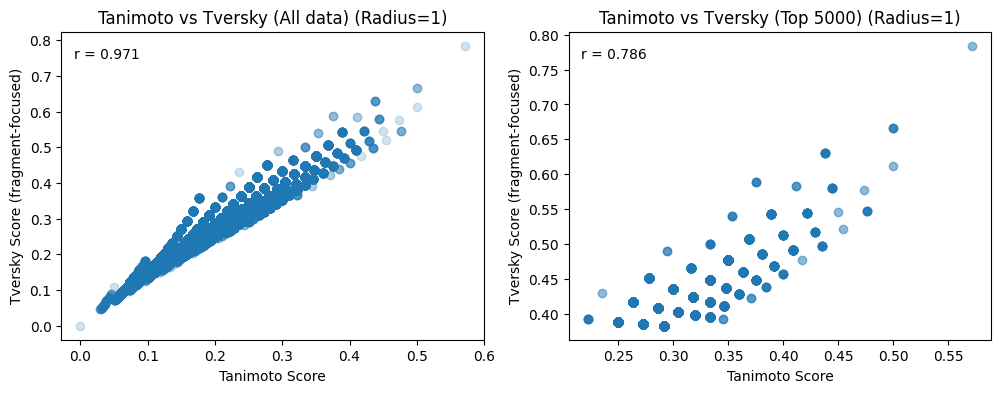

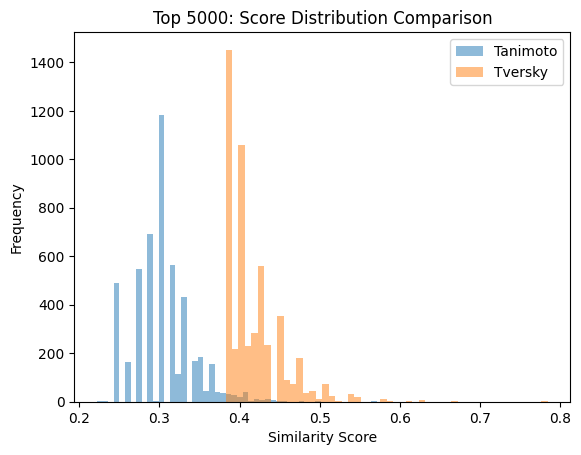

In [32]:
# P1.S Compare Tanimoto and Tversky Similarity

# Top 5000 hits
results_df_top = results_df.sort_values(by="sim_tv_frag", ascending=False).head(5000).copy()

# Correlations to display on plots
corr_all = results_df["sim_r1_tan"].corr(results_df["sim_r1_tv_frag"])
corr_top = results_df_top["sim_r1_tan"].corr(results_df_top["sim_r1_tv_frag"])

# Scatterplot comparing similarity scoring (all data and top 5000 hits)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  

# All data
plt.subplot(1,2,1)
plt.scatter(results_df["sim_r1_tan"], results_df["sim_r1_tv_frag"], alpha=0.2)
plt.title("Tanimoto vs Tversky (All data) (Radius=1)")
plt.xlabel("Tanimoto Score")
plt.ylabel("Tversky Score (fragment-focused)")
plt.text(
    0.03, 0.95, f"r = {corr_all:.3f}",
    transform=axes[0].transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

# Top 5000 subset
plt.subplot(1,2,2)
plt.scatter(results_df_top["sim_r1_tan"], results_df_top["sim_r1_tv_frag"], alpha=0.5)
plt.title("Tanimoto vs Tversky (Top 5000) (Radius=1)")
plt.xlabel("Tanimoto Score")
plt.ylabel("Tversky Score (fragment-focused)")
plt.text(
    0.03, 0.95, f"r = {corr_top:.3f}",
    transform=axes[1].transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.show()


# Disagreement molecules (biggest difference between Tanimoto and Tversky)
results_df["diff"] = results_df["sim_r1_tv_frag"] - results_df["sim_r1_tan"]
results_df.sort_values("diff", ascending=False).head(10)


# Histogram (top 5000 hits only)
plt.figure()

plt.hist(results_df_top["sim_r1_tan"], bins=50, alpha=0.5, label="Tanimoto")
plt.hist(results_df_top["sim_r1_tv_frag"], bins=50, alpha=0.5, label="Tversky")

plt.legend()
plt.title("Top 5000: Score Distribution Comparison")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()

* We compared Tanimoto and Tversky similarity metrics across the full dataset and a high-scoring subset candidates ranked by fragment-focused Tversky similarity to ensure both statistical robustness and enrichment for chemically relevant structures. While the metrics were highly correlated across all molecules (r = 0.97), this correlation decreased substantially among top 5000 candidates (r = 0.79), indicating that Tversky captures additional fragment-containment information not reflected in symmetric similarity measures. This supports the use of Tversky similarity for identifying pharmacophore-relevant structures.

Histogram analysis of top candidates shows a rightward shift in Tversky similarity scores compared to Tanimoto, consistent with reduced penalty for additional molecular features and improved sensitivity to fragment containment.

### Phase 2: Local Similarity Analysis

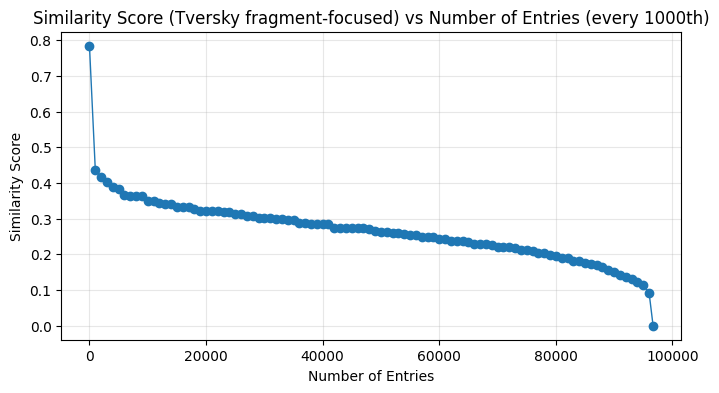

Total ranked entries: 96682
Points plotted (all-ranked): 98 (step=1000)


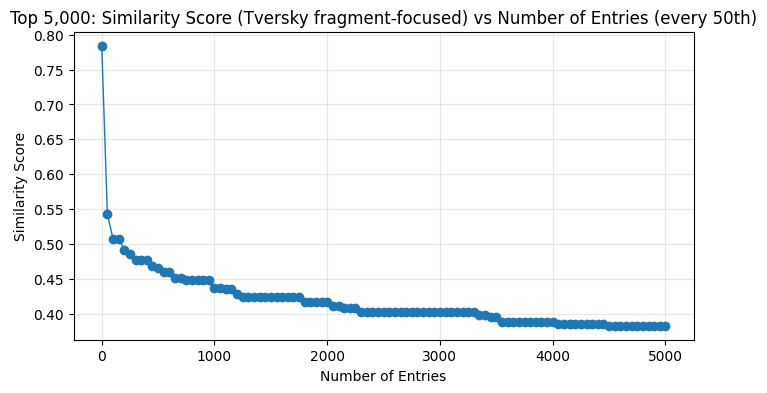

Focused range: top 5000 entries
Points plotted (top-5,000): 101 (step=50)
Subset size: 5000


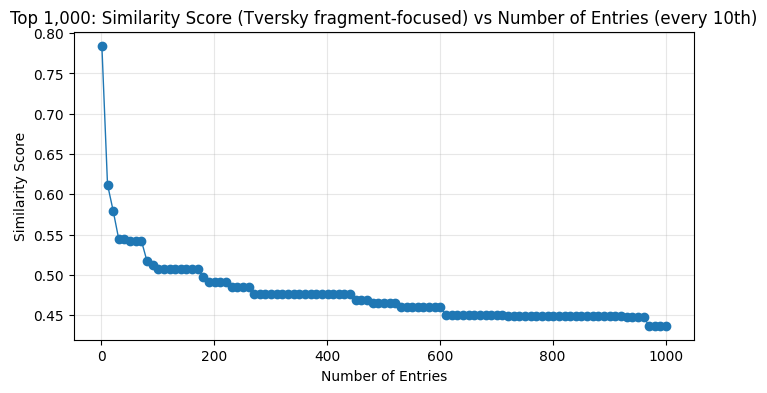

Focused range: top 1000 entries
Points plotted (top-1,000): 101 (step=10)
Subset size: 1000


In [33]:
# P2.A Rank candidates by fragment-focused Tversky and plot score trends

# Rank all candidates by similarity score (highest first)
results_ranked = (
    results_df.sort_values(by="sim_tv_frag", ascending=False)
    .reset_index(drop=True)
    .copy()
)
results_ranked["entry_n"] = np.arange(1, len(results_ranked) + 1)

# Plot 1: all ranked entries, sampled every 1000
plot_step = 1000
plot_df = results_ranked.iloc[::plot_step].copy()

# Include the last entry if it is not already included by stepping
if plot_df.iloc[-1]["entry_n"] != results_ranked.iloc[-1]["entry_n"]:
    plot_df = pd.concat([plot_df, results_ranked.tail(1)], ignore_index=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["entry_n"], plot_df["sim_tv_frag"], marker="o", linewidth=1)
plt.title("Similarity Score (Tversky fragment-focused) vs Number of Entries (every 1000th)")
plt.xlabel("Number of Entries")
plt.ylabel("Similarity Score")
plt.grid(alpha=0.3)
plt.show()

print(f"Total ranked entries: {len(results_ranked)}")
print(f"Points plotted (all-ranked): {len(plot_df)} (step={plot_step})")

# Plot 2: focused on top 5,000, sampled every 50
top_n_focus = 5000
focus_step = 50
results_top_focus = results_ranked.head(top_n_focus).copy()
focus_plot_df = results_top_focus.iloc[::focus_step].copy()

# Include the last top-N entry if not already included
if focus_plot_df.iloc[-1]["entry_n"] != results_top_focus.iloc[-1]["entry_n"]:
    focus_plot_df = pd.concat([focus_plot_df, results_top_focus.tail(1)], ignore_index=True)

plt.figure(figsize=(8, 4))
plt.plot(focus_plot_df["entry_n"], focus_plot_df["sim_tv_frag"], marker="o", linewidth=1)
plt.title("Top 5,000: Similarity Score (Tversky fragment-focused) vs Number of Entries (every 50th)")
plt.xlabel("Number of Entries")
plt.ylabel("Similarity Score")
plt.grid(alpha=0.3)
plt.show()

print(f"Focused range: top {len(results_top_focus)} entries")
print(f"Points plotted (top-5,000): {len(focus_plot_df)} (step={focus_step})")

# Keep top 5000 candidates for downstream Phase 2 cells
results_df_top = results_ranked.head(5000).copy()
print("Subset size:", len(results_df_top))

# Plot 3: focused on top 1,000, sampled every 10
top_n_focus = 1000
focus_step = 10
results_top_focus = results_ranked.head(top_n_focus).copy()
focus_plot_df = results_top_focus.iloc[::focus_step].copy()

# Include the last top-N entry if not already included
if focus_plot_df.iloc[-1]["entry_n"] != results_top_focus.iloc[-1]["entry_n"]:
    focus_plot_df = pd.concat([focus_plot_df, results_top_focus.tail(1)], ignore_index=True)

plt.figure(figsize=(8, 4))
plt.plot(focus_plot_df["entry_n"], focus_plot_df["sim_tv_frag"], marker="o", linewidth=1)
plt.title("Top 1,000: Similarity Score (Tversky fragment-focused) vs Number of Entries (every 10th)")
plt.xlabel("Number of Entries")
plt.ylabel("Similarity Score")
plt.grid(alpha=0.3)
plt.show()

print(f"Focused range: top {len(results_top_focus)} entries")
print(f"Points plotted (top-1,000): {len(focus_plot_df)} (step={focus_step})")

# Decide how many to keep for further analyis
# Keep top 5000 candidates for downstream Phase 2 cells
results_df_top = results_ranked.head(1000).copy()
print("Subset size:", len(results_df_top))


* The above plot suggests we can limit the candidate molecules to 5000 or even 1000 based on maintaining relative high similarity.  We may be limited by how many we can run using AutoDock Vina computation time, but for clustering purposes we should likely maintain a higher number to gain a good subset of features across the high-similarity candidate molecule space.

* Note on local similarity function. We're using radius = 1 and 2 on the local test which may have different results from the entire molecule test performed earlier. 
Radius 1 (very local (~1 bond))
  - Captures
     - functional groups
     - H-bond donors/acceptors
     - immediate pharmacophore features
  - Aligns with binding interactions (often very local)
  - Goes beyond only using radius = 2 which
     -  misses ultra-local matches
     - slightly dilutes pharmacophore signal
     - less sensitive to key binding atoms

Radius 2 (slightly larger (~2 bonds))
  - Captures
     - small substructures
     - ring fragmeents
     - connectivity patterns
  - Aligns with context around pharmacophore
  - Goes beyond only using radius = 1 which
     -  too local
     - can produce false positives
     - ignores structural context

In [34]:
# Debug (Should be ~10-20)
print(binding_fp_r1.GetNumOnBits(), binding_fp_r2.GetNumOnBits())

12 13


In [35]:
# Debug
mol = Chem.MolFromSmiles(results_df_top.iloc[0]["smiles"])

print("Mol atoms:", mol.GetNumAtoms())

for atom in mol.GetAtoms():
    env_fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, 2, 2048, fromAtoms=[atom.GetIdx()]
    )
    print(env_fp.GetNumOnBits())
    break

Mol atoms: 27
3


Results above indicates 
- Tversky (global) already detects the relevant fragments
- Local matching is weaker (sim_local_tv ≈ 0.2), suggesting the fragment is distributed across the molecule
NOT localized in a single compact subgraph
- Local matching adds little new information (no re-ranking, no new hits, no score improvements)
- Strong global fragment similarity and weak localized “single patch” match
- Binding motif is NOT a single tight fragment, it is distributed across multiple regions
- Local matching confirmed that the prior matching of full candidate structures was sufficient

Local substructure matching (Phase 2) did not significantly alter candidate rankings compared to fragment-weighted Tversky
similarity, indicating that relevant pharmacophore features are distributed across the molecular scaffold rather than localized in discrete substructures.

### Phase 3: Feature Clustering

In [36]:
# P3.A Input data
# Create copy of all (~97K) results ranked by Similarity Score 
# (Tversky feature-focused, radius=1)
df_ranked = results_ranked.copy() 

# Similarity Score regression target for supervised modeling
target_col = "sim_r1_tv_frag"   # Tversky feature-focused, radius=1


In [37]:
# P3.B Feature Extraction

def extract_features_safe(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        Chem.SanitizeMol(mol)

        return {
            "hbd": rdMolDescriptors.CalcNumHBD(mol),
            "hba": rdMolDescriptors.CalcNumHBA(mol),
            "rings": rdMolDescriptors.CalcNumRings(mol),
            "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "tpsa": Descriptors.TPSA(mol),
            "logp": Descriptors.MolLogP(mol),
            "mw": Descriptors.MolWt(mol),
            "amide": Fragments.fr_amide(mol),
        }

    except:
        return None

In [38]:
# P3.C Build Feature Dataframe
# Includes the regression target (Similarity Score)
def build_feature_df(df_input):
    rows = []

    for _, row in df_input.iterrows():
        feats = extract_features_safe(row["smiles"])
        if feats is None:
            continue

        feats.update({
            "name": row["name"],
            "smiles": row["smiles"],
            "sim_r1_tv_frag": row.get("sim_r1_tv_frag", np.nan)  # Regression target
        })

        rows.append(feats)

    return pd.DataFrame(rows)

In [39]:
# Run feature extraction benchmark
# Only needs to be run once to show fast processing time

# Test subset dataframe of 5000 entries
df_5000 = df_ranked.head(5000)  
start = time.time()
feat_5000 = build_feature_df(df_5000)   
t_5000 = time.time() - start

print("Feature DF sizes:", feat_5000.shape)

if len(feat_5000) > 0:
    print(f"5000 molecules: {t_5000:.2f} sec")
    print(f"Per molecule: {t_5000/len(feat_5000):.4f} sec")
    print(f"Time for all molecules: {(t_5000 * len(df_ranked)/len(df_5000)):.4f} sec")
else:
    print("ERROR: feature extraction failed")



Feature DF sizes: (5000, 11)
5000 molecules: 1.94 sec
Per molecule: 0.0004 sec
Time for all molecules: 37.4203 sec


In [40]:
# P3.D Run feature extraction

feat_all = build_feature_df(df_ranked)

print("Shapes:", feat_all.shape)
feat_all.head()

# Shared feature list for both K-Means and regression
feature_cols = [
    "hbd",
    "hba",
    "rings",
    "aromatic_rings",
    "tpsa",
    "logp",
    "mw",
    "amide",
]

# One modeling table used by unsupervised clustering and regression
# Keep "name" and "smiles" for downstream use (docking), but exclude from X_features
model_df = feat_all[["name", "smiles"] + feature_cols + [target_col]].dropna().copy()

# Inputs/target split
X_features = model_df[feature_cols]     # for K-Means and regression
y_target = model_df[target_col]         # for regression only

print("model_df shape:", model_df.shape)    
print("X_features shape:", X_features.shape)
print("y_target shape:", y_target.shape)

Shapes: (96682, 11)
model_df shape: (96682, 11)
X_features shape: (96682, 8)
y_target shape: (96682,)


In [41]:
# P3.F Apply feature scaling 

# Using all entries according to similarity (Tversky, feature-focused, radius=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features) # Scaled feature data


In [42]:
# P3.G PCA computation
pca = PCA(n_components=2, random_state=42)  # For visualizing in 2D plots
X_pca = pca.fit_transform(X_scaled)

model_df["PC1"] = X_pca[:, 0]
model_df["PC2"] = X_pca[:, 1]

var_explained = pca.explained_variance_ratio_

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols
)

print(loadings)

                     PC1       PC2
hbd             0.409415 -0.091340
hba             0.462454 -0.197082
rings           0.036354  0.562111
aromatic_rings -0.039433  0.459741
tpsa            0.608767 -0.080177
logp           -0.085398  0.310601
mw              0.481188  0.345027
amide           0.078782  0.451155


In [43]:
# P3.H K-Means functions (run K-Means and evaluate)
def run_kmeans(X, k, random_state=42):
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )
    return kmeans.fit_predict(X)


def evaluate_k(X, k_range=range(2, 15)):
    inertia = []
    silhouette_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))

    return inertia, silhouette_scores

In [44]:
# P3.I K-Means evaluation (10% sample)

k_range = range(2, 15)
sampled_frac = 0.10
n_eval = max(1000, int(len(X_scaled) * sampled_frac))
rng = np.random.default_rng(42)
eval_idx = rng.choice(len(X_scaled), size=n_eval, replace=False)
X_eval = X_scaled[eval_idx]

print(f"Running K-Means diagnostics on {n_eval:,} rows ({sampled_frac:.1%} sample) ...")
inertia, silhouette_scores = evaluate_k(X_eval, k_range)
print("Done.")

Running K-Means diagnostics on 9,668 rows (10.0% sample) ...
Done.


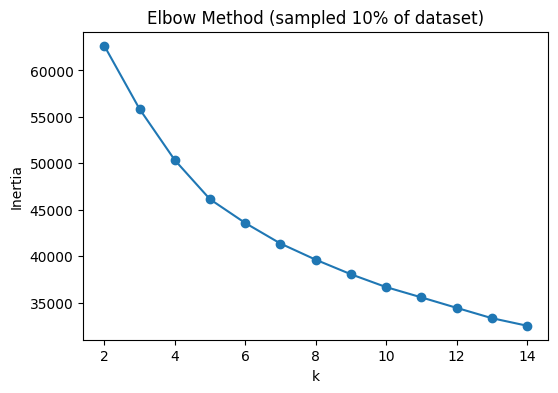

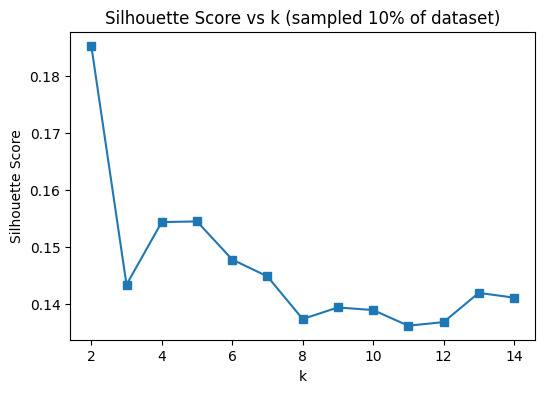

In [45]:
# P3.I K-Means evaluation (10% sample) (cont.)
# Plot K-Means results
# Plot Elbow (Inertia)
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method (sampled 10% of dataset)")
plt.show()

# Plot Silhouette
plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette_scores, marker='s')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k (sampled 10% of dataset)")
plt.show()

* Initial interpretation: 
 - The Elbow plot tracks the number of clusters (k) vs inertia (within-cluster variance), where inertia = sum of squared distances of points to their cluster centers. Inertia always drops as k increases because more clusters implies smaller goups implies tighter fits. We're looking for sharp drops where adding more stops giving big improvements (the 'elbow'). Our curve is smooth suggesitng no clear cluster structure.
 - Silhouette score is max of ~0.23 at k = 2, which suggests 2 natural clusters, but with a Silhouette score in that range it suggests weak / moderate clustering. However, given we had originally 6 features (hbd, hba, tpsa, logP, mw, rings), we're also going to look at k = 4 clusters in addition to k = 2 to potentially reveal more meaningful chemical substructure diversity.



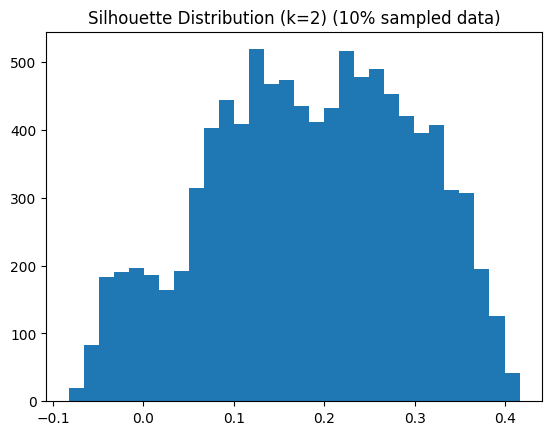

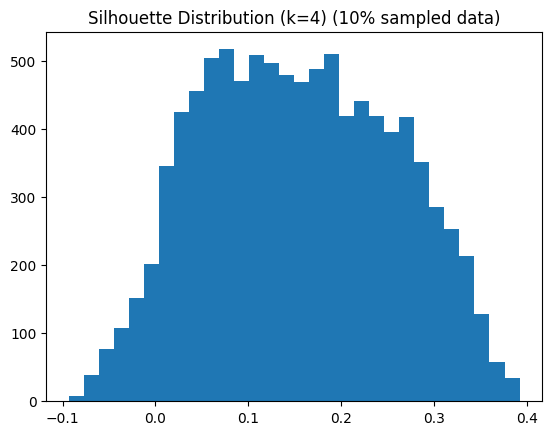

In [46]:
# P3.I K-Means evaluation (10% sample) (cont.)
# Plotting silhouette per cluster for k=2, k=4 (using 10% sampled data from earlier)
labels_eval_k2 = run_kmeans(X_eval, 2)
labels_eval_k4 = run_kmeans(X_eval, 4)

# k=2
sample_sil_k2 = silhouette_samples(X_eval, labels_eval_k2)

plt.hist(sample_sil_k2, bins=30)
plt.title("Silhouette Distribution (k=2) (10% sampled data)")
plt.show()

# k=4
sample_sil_k4 = silhouette_samples(X_eval, labels_eval_k4)

plt.hist(sample_sil_k4, bins=30)
plt.title("Silhouette Distribution (k=4) (10% sampled data)")
plt.show()


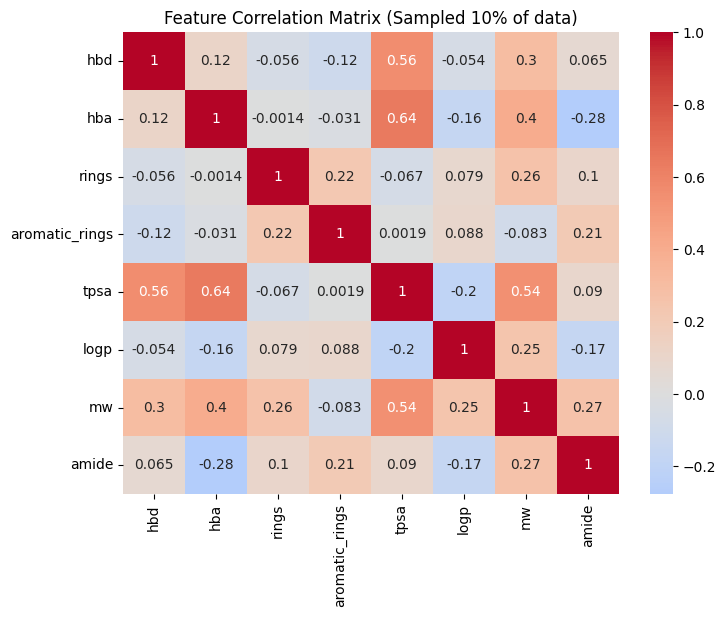

In [47]:
# P3.I K-Means evaluation (10% sample) (cont.)
# Plot feature correlations from sampled data
k_eval = 2  # or 4 depending on your decision
labels_eval = run_kmeans(X_eval, k_eval)

# Plot feature correlations (numeric columns only, same rows as X_eval)
corr_eval = feat_all.iloc[eval_idx][feature_cols]
corr_matrix = corr_eval.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (Sampled 10% of data)")
plt.show()

* Quick analysis: 

The correlation matrix reveals chemically consistent relationships between features, including fairly strong coupling between polarity (TPSA) and hydrogen bonding acceptors and donors (hba/hbd), and molecular weight. The weak global correlation between ring count and aromatic ring count reflects heterogeneous subpopulations rather than an error, as aromatic rings represent only a subset of total rings. Overall, the feature set is non-redundant and captures multiple independent chemical dimensions, supporting its suitability for clustering and dimensionality reduction.

Low correlation between hba/hbd and logP can be normal depending on the dataset. However, a near-zero correlation between total rings and aromatic rings is unexpected, since aromatic rings are a subset of total rings. This suggests either a data distribution issue (e.g., many molecules with zero rings) or a potential problem in feature extraction. Additional diagnostics such as value distributions and scatter plots should be used to confirm whether this reflects true data characteristics or a bug.

* Reasoning about k number of clusters:
k = 2 should be used as the primary clustering result because it is supported by silhouette analysis and reflects the strongest structure in the data. k = 4 can be used as a secondary, exploratory clustering to reveal finer chemical substructure, provided that the resulting clusters are interpretable add meaningful insight beyond the k = 2 partition.

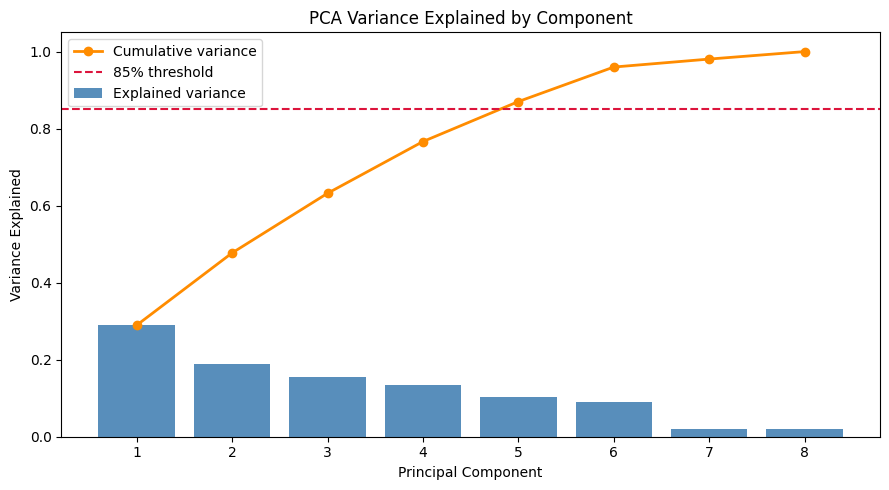

In [48]:
# P3.J PCA variance by component

pca_full = PCA()    # PCA model object

# Create PCA model from X_scaled (all data scaled features input 'X_scaled')
X_scaled_pca_full = pca_full.fit_transform(X_scaled) 

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Variance plot (bars for explained variance per component)
components = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(9, 5))
plt.bar(components, explained_var, color="steelblue", alpha=0.9, label="Explained variance")

# Cumulative variance as a line on top
plt.plot(components, cumulative_var, color="darkorange", marker="o", linewidth=2, label="Cumulative variance")

plt.axhline(0.85, linestyle="--", color="crimson", label="85% threshold")
plt.xticks(components)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Variance Explained by Component")
plt.legend()
plt.tight_layout()
plt.show()



In [49]:
# P3.K K-Means Clustering (Pharmokinetic Features Only)
# Clustering based only molecular features ("hbd", "hba", "rings", "aromatic_rings",
#    "tpsa", "logp", "mw", "amide")

# Run K-Means clustering for both k=2 and k=4 based on pharmokinetic features
labels_pharm_k2_kmeans = run_kmeans(X_scaled, 2)
labels_pharm_k4_kmeans = run_kmeans(X_scaled, 4)

In [50]:
plot_df.shape
plot_df.head()

,smiles,name,coconut_id,sim_tanimoto,sim_r1_tan,sim_r2_tan,sim_tv_sym,sim_r1_tv_sym,sim_r2_tv_sym,sim_tv_frag,sim_r1_tv_frag,sim_r2_tv_frag,diff,entry_n
0,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,CNP0124018.1,CNP0124018.1,0.571429,0.571429,0.346154,0.727273,0.727273,0.514286,0.784314,0.784314,0.426540,0.212885,1
1,COC1=CC(OC)=CC([C@H]2NCC[C@@]23C(=O)NC2=CC=C(O...,CNP0371907.1,CNP0371907.1,0.347826,0.347826,0.205128,0.516129,0.516129,0.340426,0.437158,0.437158,0.250784,0.089332,1001
2,CCOC(=O)C[C@@H]1CCN(C(=O)NC2=CC=CC=C2)C[C@@H]1...,CNP0227752.1,CNP0227752.1,0.333333,0.333333,0.204545,0.500000,0.500000,0.339623,0.416667,0.416667,0.241287,0.083333,2001
3,CC[C@H]1C[C@@H]2C[C@H]3[C@H]4C/C=C/C(=O)NCCC[C...,10-epi-deOH-HSAF,CNP0435363.1,0.304348,0.304348,0.166667,0.466667,0.466667,0.285714,0.402299,0.402299,0.200000,0.097951,3001
4,C/C(=C\[C@H](O)[C@@H](C)O)C1CC[C@H]2C3=CC(=O)[...,Neocyclocitrinol D,CNP0244542.9,0.250000,0.250000,0.125000,0.400000,0.400000,0.222222,0.387597,0.387597,0.166113,0.137597,4001


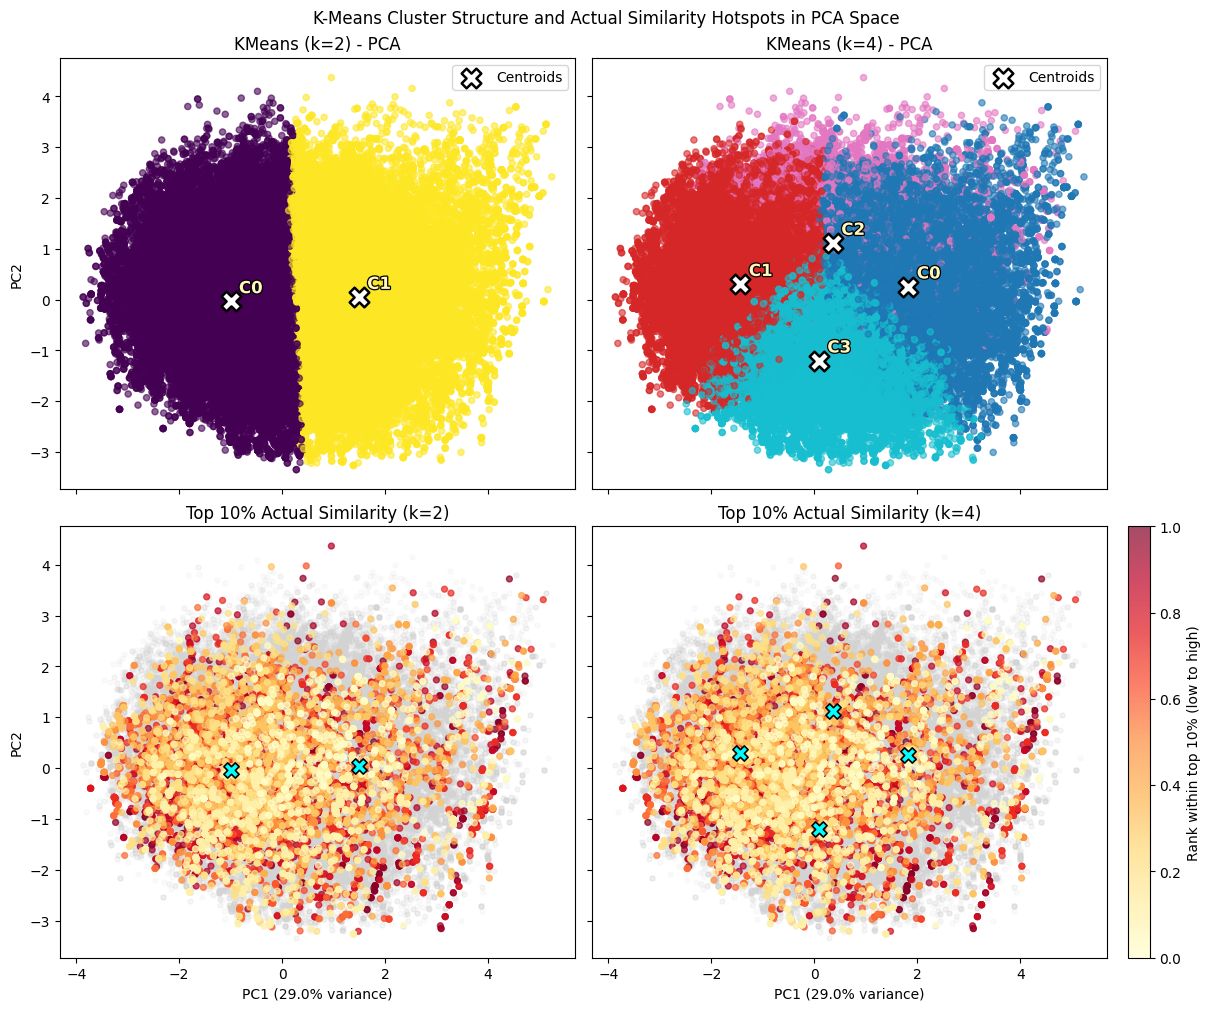

In [51]:
# P3.K Visualize K-Means using PCA 2D projection
# Top row: cluster assignments (k=2, k=4)
# Bottom row: top-similarity overlays using ACTUAL similarity scores

import matplotlib.patheffects as pe

# 2D projection for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pc_var = pca.explained_variance_ratio_

# Keep PCA coordinates aligned with model_df rows
model_df["PC1"] = X_pca[:, 0]
model_df["PC2"] = X_pca[:, 1]

plot_df = model_df.copy()
plot_df["cluster_k2"] = labels_pharm_k2_kmeans
plot_df["cluster_k4"] = labels_pharm_k4_kmeans

sim_col = "sim_r1_tv_frag"

# Highlight highest similarity subset 'top_fract' in bottom plot row
top_frac = 0.10
sim_cutoff = plot_df[sim_col].quantile(1 - top_frac)
top_df = plot_df.loc[plot_df[sim_col] >= sim_cutoff].copy()
top_df["top_rank_pct"] = top_df[sim_col].rank(pct=True)

centroids_k2 = (plot_df.groupby("cluster_k2")[["PC1", "PC2"]].mean())
centroids_k4 = (plot_df.groupby("cluster_k4")[["PC1", "PC2"]].mean())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True, constrained_layout=True)

# Top-left: k=2 clusters
axes[0, 0].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster_k2"],
    alpha=0.60,
    cmap="viridis",
    s=20
)
axes[0, 0].scatter(
    centroids_k2["PC1"],
    centroids_k2["PC2"],
    c="white",
    s=200,
    marker="X",
    edgecolors="black",
    linewidths=1.8,
    zorder=4,
    label="Centroids"
)
for cid, row in centroids_k2.iterrows():
    text = axes[0, 0].annotate(
        f"C{cid}",
        xy=(row["PC1"], row["PC2"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="#fff7bc",
        ha="left",
        va="bottom",
        zorder=5
    )
    text.set_path_effects([pe.Stroke(linewidth=1.8, foreground="black"), pe.Normal()])
axes[0, 0].set_title("KMeans (k=2) - PCA")
axes[0, 0].set_ylabel("PC2")
axes[0, 0].legend(loc="best")

# Top-right: k=4 clusters
axes[0, 1].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster_k4"],
    alpha=0.60,
    cmap="tab10",
    s=20
)
axes[0, 1].scatter(
    centroids_k4["PC1"],
    centroids_k4["PC2"],
    c="white",
    s=200,
    marker="X",
    edgecolors="black",
    linewidths=1.8,
    zorder=4,
    label="Centroids"
)
for cid, row in centroids_k4.iterrows():
    text = axes[0, 1].annotate(
        f"C{cid}",
        xy=(row["PC1"], row["PC2"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="#fff7bc",
        ha="left",
        va="bottom",
        zorder=5
    )
    text.set_path_effects([pe.Stroke(linewidth=1.8, foreground="black"), pe.Normal()])
axes[0, 1].set_title("KMeans (k=4) - PCA")
axes[0, 1].legend(loc="best")

# Bottom-left: top similarity overlay on k=2 view
axes[1, 0].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c="lightgray",
    alpha=0.10,
    s=12
)
sc_top = axes[1, 0].scatter(
    top_df["PC1"],
    top_df["PC2"],
    c=top_df["top_rank_pct"],
    cmap="YlOrRd",
    alpha=0.70,
    s=18,
    vmin=0.0,
    vmax=1.0
)
axes[1, 0].scatter(
    centroids_k2["PC1"],
    centroids_k2["PC2"],
    c="cyan",
    s=120,
    marker="X",
    edgecolors="black",
    linewidths=1.2,
    zorder=4
)
axes[1, 0].set_title(f"Top {int(top_frac*100)}% Actual Similarity (k=2)")
axes[1, 0].set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)")
axes[1, 0].set_ylabel("PC2")

# Bottom-right: top similarity overlay on k=4 view
axes[1, 1].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c="lightgray",
    alpha=0.10,
    s=12
)
axes[1, 1].scatter(
    top_df["PC1"],
    top_df["PC2"],
    c=top_df["top_rank_pct"],
    cmap="YlOrRd",
    alpha=0.70,
    s=18,
    vmin=0.0,
    vmax=1.0
)
axes[1, 1].scatter(
    centroids_k4["PC1"],
    centroids_k4["PC2"],
    c="cyan",
    s=120,
    marker="X",
    edgecolors="black",
    linewidths=1.2,
    zorder=4
)
axes[1, 1].set_title(f"Top {int(top_frac*100)}% Actual Similarity (k=4)")
axes[1, 1].set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)")

cbar = fig.colorbar(sc_top, ax=axes[1, :], fraction=0.03, pad=0.02)
cbar.set_label(f"Rank within top {int(top_frac*100)}% (low to high)")

fig.suptitle("K-Means Cluster Structure and Actual Similarity Hotspots in PCA Space")
plt.show()


/Users/sibhisak/Downloads/CHEM277A/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


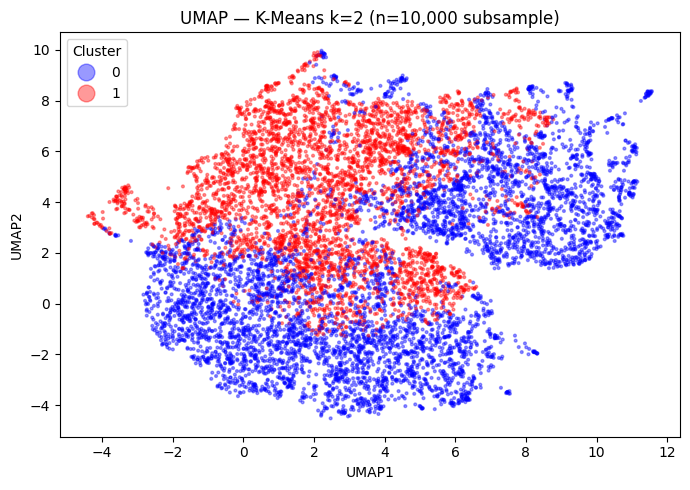

In [52]:
# P3.L UMAP cluster validation (k=2, subsampled for speed)
# Nonlinear 2D embedding to confirm K-Means cluster structure found via PCA

# Subsample for speed (10K points from ~97K)
umap_n = 10000
umap_rng = np.random.default_rng(42)
umap_idx = umap_rng.choice(len(X_scaled), size=umap_n, replace=False)
X_umap_in   = X_scaled[umap_idx]
labels_umap = labels_pharm_k2_kmeans[umap_idx]

umap_model = umap.UMAP(n_neighbors=50, min_dist=0.5, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_umap_in)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                c=labels_umap, cmap="bwr", s=4, alpha=0.4)
ax.legend(*sc.legend_elements(), title="Cluster", markerscale=2)
ax.set_title("UMAP — K-Means k=2 (n=10,000 subsample)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
plt.tight_layout()
plt.show()

* Initial UMAP analysis: Using 50 nearest neighbors and 0.5 minimum distance, the UMAP plot suggests two major regions, but with curved, nonlinear organization and partial mixing suggesting possible substructures. The blue cluster occupies two regions, separated by the red region acting as a central bridge in the non-linear manifold. While the K-Means looks for a global partition, which for k=2 clusters indicated a dominant hyrophobicity/polarity axis. UMAP suggests possible local motif neighborhoods, potentially reflecitng different scaffold classes, ring systems, and pharmacophore motifs. These further suggest that for K-Means, exploring k=4 number of clusters may reveal local substructures within the larger k=2 clustering. The chemical space exhibits by K-Means a dominant global division consistent with k=2 clustering, while UMAP's nonlinear manifold suggests additional local substructure and continuity within the broader organization. Further, given the UMAP overlap at the cluster borders, the chemical space appers more continuous rather than discretely separated. 

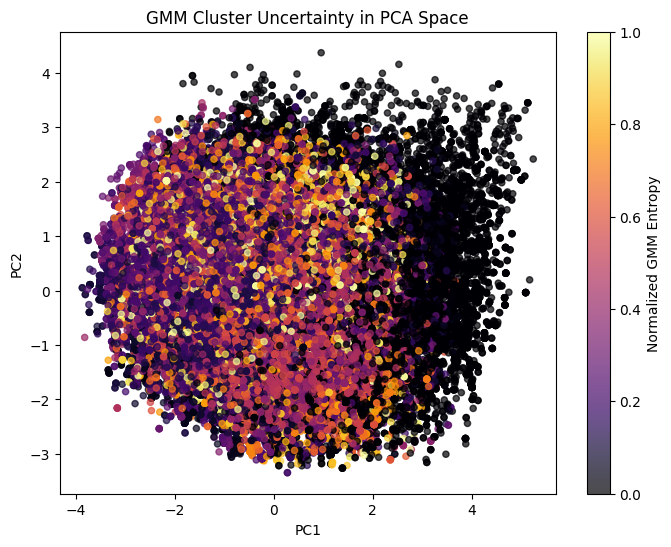

In [53]:
# (LIKELY REMOVE) P3.M GMM

from sklearn.mixture import GaussianMixture

# Fit GMM with k=2
gmm = GaussianMixture(n_components=2, covariance_type='full',random_state=42)
gmm.fit(X_scaled)

# Calculate prediction probabilities
probs_gmm = gmm.predict_proba(X_scaled)

# Calculate entropy
from scipy.stats import entropy

gmm_entropy = entropy(probs_gmm.T)
gmm_entropy_norm = gmm_entropy / np.log(2) # Normalize to 0-1 range

# Plot entropy
plot_df["gmm_entropy"] = gmm_entropy_norm

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["gmm_entropy"],
    cmap="inferno",
    s=20,
    alpha=0.7
)

cbar = plt.colorbar(scatter)
cbar.set_label("Normalized GMM Entropy")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("GMM Cluster Uncertainty in PCA Space")

plt.show()

In [54]:
# P3.L Cluster interpretation: PCA loadings and cluster mean tables

# PCA loadings
# Positive loading = feature increases along that PC axis
# Negative loading = feature decreases along that PC axis
print("PCA feature loadings (PC1 and PC2)")
display(loadings.round(3))

# Cluster means in original feature units
plot_df = model_df.copy()
plot_df["cluster_k2"] = labels_pharm_k2_kmeans
plot_df["cluster_k4"] = labels_pharm_k4_kmeans

means_k2_original = plot_df.groupby("cluster_k2")[feature_cols].mean().round(3)
means_k4_original = plot_df.groupby("cluster_k4")[feature_cols].mean().round(3)

print("Feature means (k=2 clusters)")
display(means_k2_original)
print("Feature means (k=4 clusters)")
display(means_k4_original)

PCA feature loadings (PC1 and PC2)


,PC1,PC2
hbd,0.409,-0.091
hba,0.462,-0.197
rings,0.036,0.562
aromatic_rings,-0.039,0.460
tpsa,0.609,-0.080
logp,-0.085,0.311
mw,0.481,0.345
amide,0.079,0.451


Feature means (k=2 clusters)


,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide
cluster_k2,,,,,,,,
0,1.557,4.860,3.710,1.852,78.481,3.523,399.431,0.751
1,2.570,6.417,3.868,1.749,111.224,3.445,469.332,0.905


Feature means (k=4 clusters)


,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide
cluster_k4,,,,,,,,
0,2.643,6.731,4.130,1.711,113.901,3.860,491.365,0.523
1,1.394,4.557,3.915,2.001,70.748,3.943,400.508,0.545
2,2.202,4.766,4.058,2.120,96.121,3.127,451.732,2.532
3,1.982,6.055,3.173,1.481,96.716,2.896,396.835,0.345


* Interpretation of the above: The clustering characterizes the diversity of chemical space in the candidate library. The k=2 split suggests roughly half the candidate molecules are smaller/less polar (lower MW, lower TPSA, fewer hba/hbd), and the other half are larger/more polar. The k=4 split suggests that subgroup 2 is unusually amide-rich. This doesn't say much except there's a lot of diverse candidates in the pool. 

### Regression

In [55]:
model_df.head()

,name,smiles,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag,PC1,PC2
0,CNP0124018.1,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,1,3,2,0,83.71,2.5554,379.545,3,0.784314,-1.627313,-0.919182
1,Fenestin A,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,2,4,3,0,105.80,2.7244,420.554,2,0.666667,0.044468,-0.767893
2,Fenestin B,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,3,5,3,0,138.39,3.7055,519.687,2,0.666667,2.458469,-0.144309
3,NCGC00398625-01,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,3,4,3,0,124.84,2.1380,477.650,5,0.666667,1.780624,0.518628
4,CNP0123277.2,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,2,4,4,0,92.34,3.9601,458.643,2,0.630631,-0.093286,0.581394


In [56]:
# Create regression dataframe
X = model_df.drop(columns=["name", "smiles", "sim_r1_tv_frag", "PC1", "PC2"])
y = model_df["sim_r1_tv_frag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
model_df.head()

,name,smiles,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag,PC1,PC2
0,CNP0124018.1,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,1,3,2,0,83.71,2.5554,379.545,3,0.784314,-1.627313,-0.919182
1,Fenestin A,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,2,4,3,0,105.80,2.7244,420.554,2,0.666667,0.044468,-0.767893
2,Fenestin B,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,3,5,3,0,138.39,3.7055,519.687,2,0.666667,2.458469,-0.144309
3,NCGC00398625-01,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,3,4,3,0,124.84,2.1380,477.650,5,0.666667,1.780624,0.518628
4,CNP0123277.2,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,2,4,4,0,92.34,3.9601,458.643,2,0.630631,-0.093286,0.581394


In [58]:
scaler_reg1 = StandardScaler()
X_train_scaled = scaler_reg1.fit_transform(X_train)
X_test_scaled = scaler_reg1.transform(X_test)

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [60]:
# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", rmse)
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.5344207015197581
RMSE: 0.04936407860991926
MAE: 0.03879958787911574


In [61]:
Correlation = r2_score(y_test,y_pred)**(0.5)
print(Correlation)

0.7310408343723065


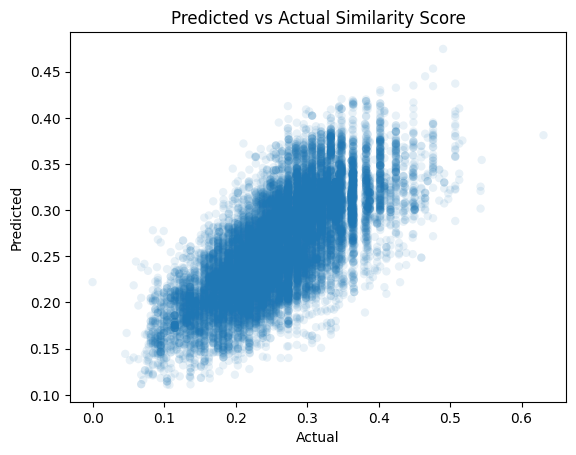

In [62]:
# Diagnostic plots
plt.scatter(y_test, y_pred, edgecolors="none", alpha=0.1)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Similarity Score")
plt.show()

* Note on banding above: Similarity scores are not truly continuous mathematically. They are discrete ratios derived overlaps from morgan fingerprint binary hashed vectors (2048 bits). Thus both numerator and denominators in similarity scoring are integers, so their ratios take on discrete fractional values. Note the tendency for the banding to increase at higher similarity scores because high-similarity molecules often only differ by a few fingerprint bits, so a more limited set of similarity values are possible. 

In [63]:
# The number of unique true similarity score values which is far smaller than ~97K samples. 
len(np.unique(y_test))

192

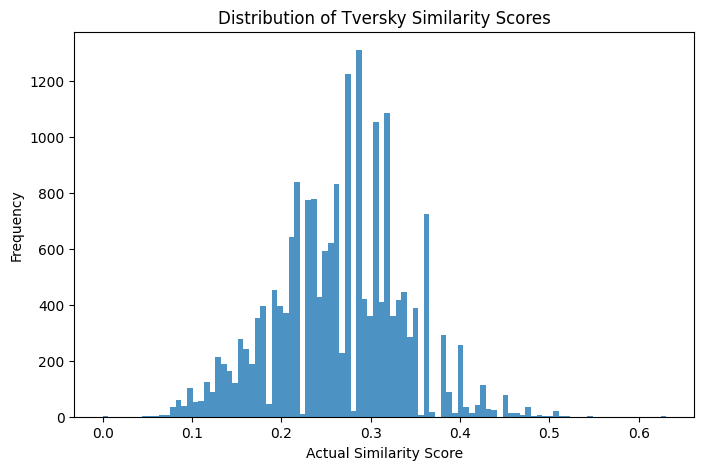

From 19337 test samples, there are only 192 number of unique similarity scores


In [64]:
# Histogram of actual similarity values:
plt.figure(figsize=(8,5))
plt.hist(y_test, bins=100, alpha=0.8)
plt.xlabel("Actual Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Tversky Similarity Scores")
plt.show()

# The number of unique true similarity score values which is far smaller than ~97K samples. 
print(f"From {len(y_test)} test samples, there are only {len(np.unique(y_test))} number of unique similarity scores")


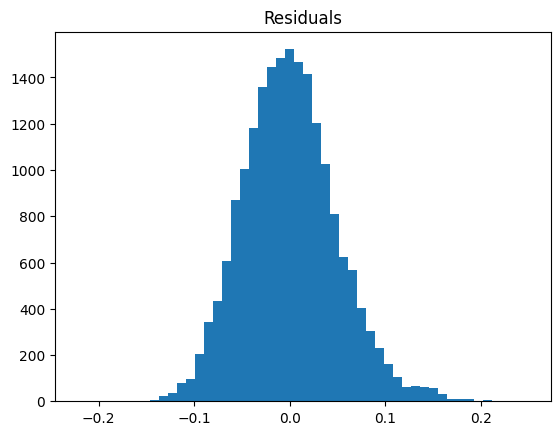

In [65]:
# (NEED TO ADD LABELS)

residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title("Residuals")
plt.show()

In [66]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

print(coef_df)

          feature  coefficient
3  aromatic_rings    -0.046540
7           amide     0.030655
1             hba    -0.016774
4            tpsa     0.014694
5            logp     0.008032
0             hbd    -0.007760
2           rings    -0.003073
6              mw    -0.002215


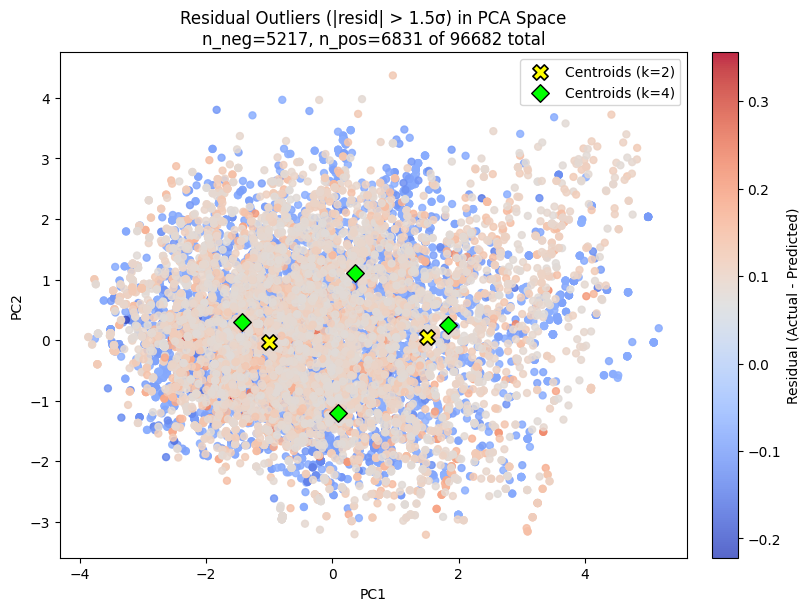

In [67]:
# Residual diff overlay — outliers only (beyond ±n_std standard deviations)
# plot_df, centroids_k2, centroids_k4 already computed above

# Predict on full dataset so every row in plot_df has a residual
X_all = model_df.drop(columns=["name", "smiles", "sim_r1_tv_frag", "PC1", "PC2"])
X_all_scaled = scaler_reg1.transform(X_all)
y_pred_all = model.predict(X_all_scaled)
plot_df["resid_diff"] = model_df["sim_r1_tv_frag"].values - y_pred_all

n_std = 1.5
mean_r = plot_df["resid_diff"].mean()
std_r  = plot_df["resid_diff"].std()

neg_out = plot_df[plot_df["resid_diff"] < mean_r - n_std * std_r]
pos_out = plot_df[plot_df["resid_diff"] > mean_r + n_std * std_r]

vmin = neg_out["resid_diff"].min() if not neg_out.empty else -1
vmax = pos_out["resid_diff"].max() if not pos_out.empty else  1

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

ax.scatter(neg_out["PC1"], neg_out["PC2"], c=neg_out["resid_diff"], cmap="coolwarm",
           alpha=0.85, s=25, vmin=vmin, vmax=vmax, zorder=2)
sc = ax.scatter(pos_out["PC1"], pos_out["PC2"], c=pos_out["resid_diff"], cmap="coolwarm",
                alpha=0.85, s=25, vmin=vmin, vmax=vmax, zorder=3)

ax.scatter(centroids_k2["PC1"], centroids_k2["PC2"],
           c="yellow", s=120, marker="X", edgecolors="black", linewidths=1.2, zorder=5,
           label="Centroids (k=2)")
ax.scatter(centroids_k4["PC1"], centroids_k4["PC2"],
           c="lime", s=80, marker="D", edgecolors="black", linewidths=1.0, zorder=5,
           label="Centroids (k=4)")

cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Residual (Actual - Predicted)")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Residual Outliers (|resid| > {n_std}σ) in PCA Space\n"
             f"n_neg={len(neg_out)}, n_pos={len(pos_out)} of {len(plot_df)} total")
ax.legend(loc="upper right")
plt.show()

## Model Improvement Techniques:
- correlation analysis -> feature pruning
- stratified train/test split 
- regularization (Ridge, Lasso, Elastic Net)
- kfold cross-validation
- PCA

THIS SECTION BELOW ADDRESSES THE PRELIMINARY DOCKING STEPS

Phase 5: Docking Binding Affinity (using AutoDoc Vina) 
A. Lock candidate selection (from sensitivity analysis)
B. Map similarity
C. Select docking candidates
D. Extract real FKBP12 binding site (from PDB)
E. Validate docking box (numerical + visual)
F. Prepare ligands
G. Prepare receptor
H. Run docking
I. Analyze results (tie back to PCA clusters)

In [68]:
# Quick check to verify original contents of 'plot_df' used in K-Means
plot_df.head()

,name,smiles,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag,PC1,PC2,cluster_k2,cluster_k4,resid_diff
0,CNP0124018.1,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,1,3,2,0,83.71,2.5554,379.545,3,0.784314,-1.627313,-0.919182,0,2,0.355820
1,Fenestin A,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,2,4,3,0,105.80,2.7244,420.554,2,0.666667,0.044468,-0.767893,0,2,0.276975
2,Fenestin B,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,3,5,3,0,138.39,3.7055,519.687,2,0.666667,2.458469,-0.144309,1,0,0.269751
3,NCGC00398625-01,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,3,4,3,0,124.84,2.1380,477.650,5,0.666667,1.780624,0.518628,1,2,0.190227
4,CNP0123277.2,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,2,4,4,0,92.34,3.9601,458.643,2,0.630631,-0.093286,0.581394,0,2,0.242570


In [69]:
# Troubleshooting
binding_df = plot_df.copy().drop(columns=["PC1", "PC2"]) 
#binding_df.drop(columns=["PC1", "PC2"])  # Remove original PCA loadings
binding_df.head()

binding_df_C0 = binding_df[binding_df["cluster_k2"] == 0]
binding_df_C1 = binding_df[binding_df["cluster_k2"] == 1]
binding_df_C0.size + binding_df_C1.size - binding_df.size  # verify 0

ratio_C0 = binding_df_C0.size /  binding_df.size
ratio_C1 = binding_df_C1.size /  binding_df.size
print(f"Fraction of dataframe in Cluster 0: {ratio_C0}")
print(f"Fraction of dataframe in Cluster 1: {ratio_C1}")
print(ratio_C0 + ratio_C1)

n_samples_total = 1000    # Total # samples for binding
n_samples_C0_PerQ = round((n_samples_total * ratio_C0) / 4, 0)
n_samples_C1_PerQ = round((n_samples_total * ratio_C1) / 4, 0)
n_samples_C0_PerQ = int(n_samples_C0_PerQ)
n_samples_C1_PerQ = int(n_samples_C1_PerQ)


print(f"Number of samples per quartile (C0): {n_samples_C0_PerQ} ")
print(f"Number of samples per quartile (C1): {n_samples_C1_PerQ} ")
print(f"Total samples: {4 * (n_samples_C0_PerQ + n_samples_C1_PerQ) }")


n_samples_total = 500 

# Identify similarity score column used for ordering
similarity_col = "sim_r1_tv_frag"

# Create binding molecules dataframe
# Copy full dataset used in K-Means and remove original PCA loadings
binding_df = plot_df.copy().drop(columns=["PC1", "PC2", "cluster_k4"])
binding_df = binding_df.sort_values(by=similarity_col, ascending=False).reset_index(drop=True)

binding_df_C0 = binding_df[binding_df["cluster_k2"] == 0]
binding_df_C1 = binding_df[binding_df["cluster_k2"] == 1]

binding_df_C0["quartile"] = pd.qcut(binding_df_C0[similarity_col], q=4, labels=[3, 2, 1, 0])
binding_df_C1["quartile"] = pd.qcut(binding_df_C1[similarity_col], q=4, labels=[3, 2, 1, 0])

sample_C0 = binding_df_C0.groupby("quartile", group_keys=False).sample(n=n_samples_C0_PerQ, random_state=42)
sample_C1 = binding_df_C1.groupby("quartile", group_keys=False).sample(n=n_samples_C1_PerQ, random_state=42)

binding_candidates = pd.concat([sample_C0, sample_C1]).reset_index(drop=True)

print(f"C0 samples: {len(sample_C0)} ({n_samples_C0_PerQ} in each of 4 quartiles)")
print(f"C1 samples: {len(sample_C1)} ({n_samples_C1_PerQ} in each of 4 quartiles)")
print(f"Total binding candidates: {len(binding_candidates)}")

print(f"Size of C0/quartile 0: {len(binding_candidates[(binding_candidates['cluster_k2'] == 0) & (binding_candidates['quartile'] == 0)])}")
print(f"Size of C0/quartile 1: {len(binding_candidates[(binding_candidates['cluster_k2'] == 0) & (binding_candidates['quartile'] == 1)])}")
print(f"Size of C0/quartile 2: {len(binding_candidates[(binding_candidates['cluster_k2'] == 0) & (binding_candidates['quartile'] == 2)])}")
print(f"Size of C0/quartile 3: {len(binding_candidates[(binding_candidates['cluster_k2'] == 0) & (binding_candidates['quartile'] == 3)])}")
print(f"Size of C1/quartile 0: {len(binding_candidates[(binding_candidates['cluster_k2'] == 1) & (binding_candidates['quartile'] == 0)])}")
print(f"Size of C1/quartile 1: {len(binding_candidates[(binding_candidates['cluster_k2'] == 1) & (binding_candidates['quartile'] == 1)])}")
print(f"Size of C1/quartile 2: {len(binding_candidates[(binding_candidates['cluster_k2'] == 1) & (binding_candidates['quartile'] == 2)])}")
print(f"Size of C1/quartile 2: {len(binding_candidates[(binding_candidates['cluster_k2'] == 1) & (binding_candidates['quartile'] == 3)])}")


Fraction of dataframe in Cluster 0: 0.5980430690304297
Fraction of dataframe in Cluster 1: 0.40195693096957036
1.0
Number of samples per quartile (C0): 150 
Number of samples per quartile (C1): 100 
Total samples: 1000
C0 samples: 600 (150 in each of 4 quartiles)
C1 samples: 400 (100 in each of 4 quartiles)
Total binding candidates: 1000
Size of C0/quartile 0: 150
Size of C0/quartile 1: 150
Size of C0/quartile 2: 150
Size of C0/quartile 3: 150
Size of C1/quartile 0: 100
Size of C1/quartile 1: 100
Size of C1/quartile 2: 100
Size of C1/quartile 2: 100


In [70]:
# Troubleshooting 
"""
n_samples_total = 1000
similarity_col = "sim_r1_tv_frag"

# Create binding molecules dataframe
# Copy full dataset used in K-Means and remove original PCA loadings
docking_df = plot_df.copy().drop(columns=["PC1", "PC2", "cluster_k4"])
docking_df = docking_df.sort_values(by=similarity_col, ascending=False).reset_index(drop=True)

docking_df_C0 = docking_df[docking_df["cluster_k2"] == 0]
docking_df_C1 = docking_df[docking_df["cluster_k2"] == 1]

ratio_C0 = docking_df_C0.size /  docking_df.size
ratio_C1 = docking_df_C1.size /  docking_df.size
print(f"Fraction of dataframe in Cluster 0: {ratio_C0}")
print(f"Fraction of dataframe in Cluster 1: {ratio_C1}")

n_samples_C0_PerQ = round((n_samples_total * ratio_C0) / 4, 0)
n_samples_C1_PerQ = round((n_samples_total * ratio_C1) / 4, 0)
n_samples_C0_PerQ = int(n_samples_C0_PerQ)
n_samples_C1_PerQ = int(n_samples_C1_PerQ)

docking_df_C0["quartile"] = pd.qcut(docking_df_C0[similarity_col], q=4, labels=[3, 2, 1, 0])
docking_df_C1["quartile"] = pd.qcut(docking_df_C1[similarity_col], q=4, labels=[3, 2, 1, 0])
sample_C0 = docking_df_C0.groupby("quartile", group_keys=False).sample(n=n_samples_C0_PerQ, random_state=42)
sample_C1 = docking_df_C1.groupby("quartile", group_keys=False).sample(n=n_samples_C1_PerQ, random_state=42)

docking_candidates_df = pd.concat([sample_C0, sample_C1]).reset_index(drop=True)

print(f"C0 samples: {len(sample_C0)} ({n_samples_C0_PerQ} in each of 4 quartiles)")
print(f"C1 samples: {len(sample_C1)} ({n_samples_C1_PerQ} in each of 4 quartiles)")
print(f"Total # docking candidates: {len(docking_candidates_df)}")

print(f"Size of C0/quartile 0: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 0) & (docking_candidates_df['quartile'] == 0)])}")
print(f"Size of C0/quartile 1: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 0) & (docking_candidates_df['quartile'] == 1)])}")
print(f"Size of C0/quartile 2: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 0) & (docking_candidates_df['quartile'] == 2)])}")
print(f"Size of C0/quartile 3: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 0) & (docking_candidates_df['quartile'] == 3)])}")
print(f"Size of C1/quartile 0: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 1) & (docking_candidates_df['quartile'] == 0)])}")
print(f"Size of C1/quartile 1: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 1) & (docking_candidates_df['quartile'] == 1)])}")
print(f"Size of C1/quartile 2: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 1) & (docking_candidates_df['quartile'] == 2)])}")
print(f"Size of C1/quartile 2: {len(docking_candidates_df[(docking_candidates_df['cluster_k2'] == 1) & (docking_candidates_df['quartile'] == 3)])}")
"""

'\nn_samples_total = 1000\nsimilarity_col = "sim_r1_tv_frag"\n\n# Create binding molecules dataframe\n# Copy full dataset used in K-Means and remove original PCA loadings\ndocking_df = plot_df.copy().drop(columns=["PC1", "PC2", "cluster_k4"])\ndocking_df = docking_df.sort_values(by=similarity_col, ascending=False).reset_index(drop=True)\n\ndocking_df_C0 = docking_df[docking_df["cluster_k2"] == 0]\ndocking_df_C1 = docking_df[docking_df["cluster_k2"] == 1]\n\nratio_C0 = docking_df_C0.size /  docking_df.size\nratio_C1 = docking_df_C1.size /  docking_df.size\nprint(f"Fraction of dataframe in Cluster 0: {ratio_C0}")\nprint(f"Fraction of dataframe in Cluster 1: {ratio_C1}")\n\nn_samples_C0_PerQ = round((n_samples_total * ratio_C0) / 4, 0)\nn_samples_C1_PerQ = round((n_samples_total * ratio_C1) / 4, 0)\nn_samples_C0_PerQ = int(n_samples_C0_PerQ)\nn_samples_C1_PerQ = int(n_samples_C1_PerQ)\n\ndocking_df_C0["quartile"] = pd.qcut(docking_df_C0[similarity_col], q=4, labels=[3, 2, 1, 0])\ndocking_

In [71]:
# P5.A Lock candidate selection

# Optional test mode: randomly sample a smaller set from docking_candidates_df
USE_RANDOM_TEST_SET = False     # Set to True if you want to create a randomly generated test set
RANDOM_TEST_SET_SIZE = 25
RANDOM_SEED = 42

LOCK_FINAL_TEST_SET = True      # Set to True to keep earlier full docking test set runs intact

if not LOCK_FINAL_TEST_SET and not USE_RANDOM_TEST_SET:
    # DEFINE TOTAL SAMPLE SIZE FOR BINDING:
    n_samples_total = 1000    

    # Identify similarity score column used for ordering
    similarity_col = "sim_r1_tv_frag"

    # Create binding molecules dataframe
    # Copy full dataset used in K-Means and remove original PCA loadings
    docking_df = plot_df.copy().drop(columns=["PC1", "PC2", "cluster_k4"])
    docking_df = docking_df.sort_values(by=similarity_col, ascending=False).reset_index(drop=True)

    # Split between Cluster 0 and Cluster 1 (k=2)
    docking_df_C0 = docking_df[docking_df["cluster_k2"] == 0]
    docking_df_C1 = docking_df[docking_df["cluster_k2"] == 1]

    # Calculate ratio of Cluster 0 and Cluster 1
    ratio_C0 = docking_df_C0.size /  docking_df.size
    ratio_C1 = docking_df_C1.size /  docking_df.size
    print(f"Fraction of dataframe in Cluster 0: {ratio_C0}")
    print(f"Fraction of dataframe in Cluster 1: {ratio_C1}")

    # Identify number of samples in C0 and C1 in each similarity score quartile
    n_samples_C0_PerQ = round((n_samples_total * ratio_C0) / 4, 0)
    n_samples_C1_PerQ = round((n_samples_total * ratio_C1) / 4, 0)
    n_samples_C0_PerQ = int(n_samples_C0_PerQ)
    n_samples_C1_PerQ = int(n_samples_C1_PerQ)

    # Extract C0 and C1 samples by quartile
    docking_df_C0["quartile"] = pd.qcut(docking_df_C0[similarity_col], q=4, labels=[3, 2, 1, 0])
    docking_df_C1["quartile"] = pd.qcut(docking_df_C1[similarity_col], q=4, labels=[3, 2, 1, 0])
    sample_C0 = docking_df_C0.groupby("quartile", group_keys=False).sample(n=n_samples_C0_PerQ, random_state=42)
    sample_C1 = docking_df_C1.groupby("quartile", group_keys=False).sample(n=n_samples_C1_PerQ, random_state=42)


    docking_candidates_df = pd.concat([sample_C0, sample_C1]).reset_index(drop=True)
    
    # Save backup in case of problem
    DOCKING_CANDIDATES_FILE = "docking_candidates.pkl"
    docking_candidates_backup_df = docking_candidates_df.copy()     # Saving a copy in case of a problem
    with open(DOCKING_CANDIDATES_FILE, "wb") as f:
        pickle.dump(docking_candidates_backup_df, f)

    
    print(f"C0 samples: {len(sample_C0)} ({n_samples_C0_PerQ} in each of 4 quartiles)")
    print(f"C1 samples: {len(sample_C1)} ({n_samples_C1_PerQ} in each of 4 quartiles)")
    print(f"Total docking candidates: {len(docking_candidates_df)}")


if USE_RANDOM_TEST_SET:
    n_sample = RANDOM_TEST_SET_SIZE
    docking_candidates_df = docking_candidates_df.sample(
        n=n_sample,
        random_state=RANDOM_SEED
    ).reset_index(drop=True)
    print(f"Using random test set: {n_sample} rows (seed={RANDOM_SEED})")

print("Selected for docking:")
print(f"Total rows: {len(docking_candidates_df)}")


Selected for docking:


NameError: name 'docking_candidates_df' is not defined

In [ ]:
docking_df.head()


,name,smiles,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag,cluster_k2,resid_diff
0,CNP0124018.1,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,1,3,2,0,83.71,2.5554,379.545,3,0.784314,0,0.355820
1,Fenestin B,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,3,5,3,0,138.39,3.7055,519.687,2,0.666667,1,0.269751
2,NCGC00398625-01,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,3,4,3,0,124.84,2.1380,477.650,5,0.666667,1,0.190227
3,Fenestin A,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,2,4,3,0,105.80,2.7244,420.554,2,0.666667,0,0.276975
4,CNP0123277.2,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,2,4,4,0,92.34,3.9601,458.643,2,0.630631,0,0.242570


In [72]:
# P5.B Extract rapamycin binding site (numerical)

parser = PDBParser(QUIET=True)
structure = parser.get_structure("FKBP12", "1FKB.pdb")

ligand_coords_list = []

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.get_resname() == "RAP":
                for atom in residue:
                    ligand_coords_list.append(atom.coord)

ligand_coords = np.array(ligand_coords_list)

# Compute center (actual ligand location)
center_coords = ligand_coords.mean(axis=0)
print("Center:", center_coords)

# Compute box size (pocket size)
min_coords = ligand_coords.min(axis=0)
max_coords = ligand_coords.max(axis=0)

box_size_coords = (max_coords - min_coords) + 5
print("Box size:", box_size_coords)

Center: [ 3.1993816 12.129957  13.313499 ]
Box size: [17.060001 19.328999 15.177   ]


True
True


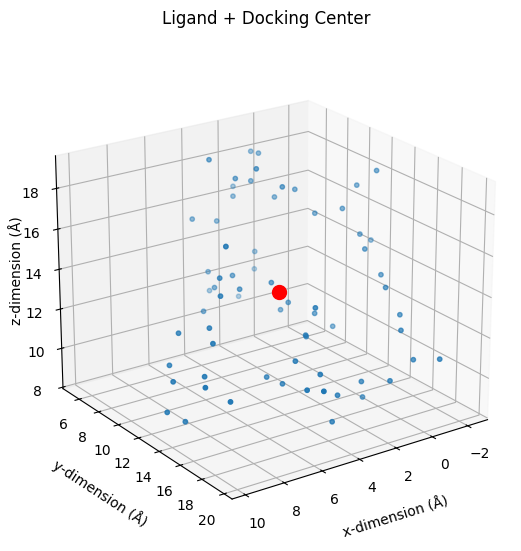

In [73]:
# P5.C Validate rapamycin docking box (numerical and visual)
# Numerical validation
box_min = center_coords - box_size_coords/2
box_max = center_coords + box_size_coords/2

print((min_coords >= box_min).all())    # Expected true
print((max_coords <= box_max).all())    # Expected true

# Visual validation
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(ligand_coords[:, 0], ligand_coords[:, 1], ligand_coords[:, 2], s=10)
ax.scatter(center_coords[0], center_coords[1], center_coords[2], color='red', s=100)

ax.set_title("Ligand + Docking Center", pad=18)
ax.set_xlabel("x-dimension (Å)", labelpad=10)
ax.set_ylabel("y-dimension (Å)", labelpad=10)
ax.set_zlabel("")

# Matplotlib 3D z-labels are often clipped in notebook renders, so place it as 2D figure text.
ax.text2D(-0.02, 0.55, "z-dimension (Å)", transform=ax.transAxes, rotation=90, va='center')

ax.view_init(elev=22, azim=55)
ax.set_box_aspect((1.1, 1.1, 0.9))
fig.subplots_adjust(left=0.10, right=0.92, bottom=0.08, top=0.90)

plt.show()

In [74]:
# P5.G Prepare ligands 

import pickle
from pathlib import Path

# Cache controls
RECOMPUTE_LIGANDS = False
LIGANDS_PICKLE_PATH = "ligand_pdbqt_data.pkl"

def prepare_ligand_pdbqt(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")

    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.UFFOptimizeMolecule(mol)

    prep = MoleculePreparation()
    prep.prepare(mol)

    return prep.write_pdbqt_string()


if RECOMPUTE_LIGANDS:
    ligand_pdbqt_data = []
    failed = []

    for _, row in docking_candidates_df.iterrows():
        try:
            pdbqt_str = prepare_ligand_pdbqt(row["smiles"])
            ligand_pdbqt_data.append((row["name"], pdbqt_str))
        except Exception as e:
            failed.append((row["name"], str(e)))

    with open(LIGANDS_PICKLE_PATH, "wb") as f:
        pickle.dump(ligand_pdbqt_data, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Saved {len(ligand_pdbqt_data)} ligands to {LIGANDS_PICKLE_PATH}")
    print(f"Failed: {len(failed)}")

else:
    if not Path(LIGANDS_PICKLE_PATH).exists():
        raise FileNotFoundError(
            f"{LIGANDS_PICKLE_PATH} not found. Set RECOMPUTE_LIGANDS = True to create it."
        )

    with open(LIGANDS_PICKLE_PATH, "rb") as f:
        ligand_pdbqt_data = pickle.load(f)

    print(f"Loaded {len(ligand_pdbqt_data)} ligands from {LIGANDS_PICKLE_PATH}")

Loaded 984 ligands from ligand_pdbqt_data.pkl


In [75]:
# P5.H Prepare receptor
# Remove ligand (rapamycin)
# Remove waters
# Add hydrogens
# Save as fkbp12.pdbqt

# Load and clean protein

import subprocess

# -------- Step 1: Clean the PDB --------
input_pdb = "1FKB.pdb"
clean_pdb = "1FKB_clean.pdb"
output_pdbqt = "fkbp12.pdbqt"

with open(input_pdb) as f:
    lines = f.readlines()

clean_lines = []

for line in lines:
    # Remove ligand (rapamycin) and water
    if line.startswith("HETATM"):
        if "RAP" in line or "HOH" in line:
            continue
    clean_lines.append(line)

with open(clean_pdb, "w") as f:
    f.writelines(clean_lines)

print(f"Saved cleaned PDB: {clean_pdb}")


# -------- Step 2: Convert to PDBQT using Open Babel --------
# Requires: Open Babel installed (obabel command available)

OBABEL_PATH = "/opt/homebrew/bin/obabel"  

cmd = [
    OBABEL_PATH,
    clean_pdb,
    "-O", output_pdbqt,
    "-xr",   # receptor mode
    "-xh"    # add hydrogens
]

try:
    subprocess.run(cmd, check=True)
    print(f"Saved receptor: {output_pdbqt}")
except Exception as e:
    print("ERROR running Open Babel:")
    print(e)


# -------- Step 3: Quick validation --------
try:
    with open(output_pdbqt) as f:
        first_line = f.readline()
    print("PDBQT file looks valid:", first_line.strip())
except:
    print("Could not validate PDBQT file.")


Saved cleaned PDB: 1FKB_clean.pdb
ERROR running Open Babel:
[Errno 2] No such file or directory: '/opt/homebrew/bin/obabel'
Could not validate PDBQT file.


* Justification for above prepare receptor section. We started with FKBP12 protein (from the 1FKB structure). This structure contains the rapamycin bound ligand, water molecules and no hydrogens (typically). We're trying to find new molecules that would bind to FKBP12, so we need protein only, correct chemistry, no interference from the existing rapamycin ligand. Thus we must first remove the rapamycin ligand from it so new molecules can bind to it. We remove water molecules (found from the crystallographic depiction) because crystallographic waters are often incomplete, sometimes artifacts, and not consistently present biologically. Keeping them would potentially block the binding pocket, add noise, and distort docking scores. 

We add hydrogens because PDB files usually do not include hydrogens (X-ray crystallography doesn't resolve them well). Docking needs them for hydrogen bond interactions, correct protonation states, and electrostatics. Without hydrogens we would have the wrong binding energies, miss interactions, and produce non-physical results. 

We convert to a PDBQT format because AutoDoc Vina requires atom types, partial charges, and specific formatting. We end up with fkbp12.pdbqt file which contains the final docking-ready receptor. 

We want to test new keys in a lock, so we have to remove the old key (rapamycin), clear debris (water), and define the lock shape (protein).

The original 1FKBP entry is 'Human FKBP12 protein crystallized in complex with rapamycin'. 
See below to run the analysis:
Code (Meaning):
  - RAP (rapamycin)
  - HOH (water)
  - ATP (ATP)
  - GOL (glycerol)

Future work:
  - Extract rapamycin coordinates
  - Visualize binding pocket residues (the amino acids making the FKBP12 protein chain)
  - Compare docking poses vs native rapamycin

FKBP12 is a 3D surface with a groove, where the groove is the binding pocket, the walls of the groove are the residues, adn the ligand (rapamycin) sits inside the groove. 

The residues form hydrogen bonds, create hydrophobic contacts, and define the shape of the pocket.
e.g.
  - Phe, Tyr -> hydrophobic stacking
  - Asp -> hydrogen bonds
  - Leu -> hydrophobic contacts

We define a 3.5 angstrom distance cutoff when detecting residues from the ligand. This distance provides mostly direct hydrogen bonds, tight van der Walls contacts, and the 'core' interaction residues (high confidence, minimal set)

Future work, we might consider second-shell hydrophobic contacts (4-6 angstroms), pocket-shaping residues (defining cavity geometry), resides that interact with larger ligands in slightly different poses. We should also consider a 5.0 or 6.0 angstrom set. A good binder might overlap partially with 3.5 Å residues and strongly overlap with 5–6 Å pocket. 

In [76]:
# Verifying 1FKBP entry

with open("1FKB.pdb") as f:
    lines = f.readlines()

# Look for rapamycin entries
rap_lines = [l for l in lines if "RAP" in l]

print("Number of RAP lines:", len(rap_lines))
print(rap_lines[:5])

Number of RAP lines: 72
['TITLE     ATOMIC STRUCTURE OF THE RAPAMYCIN HUMAN IMMUNOPHILIN FKBP-12 COMPLEX  \n', 'JRNL        TITL   ATOMIC STRUCTURE OF THE RAPAMYCIN HUMAN IMMUNOPHILIN FKBP-12 \n', 'HETNAM     RAP RAPAMYCIN IMMUNOSUPPRESSANT DRUG                                 \n', 'FORMUL   2  RAP    C51 H79 N O13                                                \n', 'HETATM 1030  C1  RAP A 108       4.633   8.500  12.847  1.00  5.98           C  \n']


In [77]:
# P5.I_pre: Load docking results from pickle (skip re-running docking)
# Set SKIP_DOCKING = True to load previously saved results from the checkpoint file
# Set SKIP_DOCKING = False to run (or resume) the full docking pipeline below
SKIP_DOCKING = True

CHECKPOINT_FILE = "docking_checkpoint.pkl"
DOCKING_CANDIDATES_FILE = "docking_candidates.pkl"

if SKIP_DOCKING:
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, "rb") as f:
            docking_output = pickle.load(f)
        print(f"Loaded {len(docking_output)} docking results from '{CHECKPOINT_FILE}'")

        with open(DOCKING_CANDIDATES_FILE, "rb") as g:
            docking_candidates_df = pickle.load(g)
        print(f"Loaded {len(docking_candidates_df)} docking candidates from '{DOCKING_CANDIDATES_FILE}'")

    else:
        print(f"WARNING: '{CHECKPOINT_FILE}' not found. Set SKIP_DOCKING = False to run docking.")
        docking_output = []


Loaded 984 docking results from 'docking_checkpoint.pkl'
Loaded 1000 docking candidates from 'docking_candidates.pkl'


In [78]:
# P5.I Run docking
if not SKIP_DOCKING:
    exhaustiveness_num = 8
    num_poses = 9

    # Recompute mode: if SKIP_DOCKING is False, always run docking from scratch
    # and overwrite checkpoint contents with fresh results.
    docking_output = []
    print("Starting fresh docking run (recomputing all ligands)")

    TOTAL = len(ligand_pdbqt_data)

    # Initialize vina
    v = Vina(sf_name='vina')
    v.set_receptor("fkbp12.pdbqt")

    # Use fixed size box
    BOX_SIZE = [25, 25, 25]

    v.compute_vina_maps(center=center_coords.tolist(), box_size=BOX_SIZE)

    # Docking loop
    for i, (name, pdbqt_str) in enumerate(ligand_pdbqt_data):
        try:
            v.set_ligand_from_string(pdbqt_str)
            v.dock(exhaustiveness=exhaustiveness_num, n_poses=num_poses)

            score = v.score()[0]
            docking_output.append((name, score))

        except Exception as e:
            print(f"Failed: {name}")
            continue

        # Save checkpoint file every 25 ligands
        if (i + 1) % 25 == 0:
            with open(CHECKPOINT_FILE, "wb") as f:
                pickle.dump(docking_output, f)
            print(f"Checkpoint saved at {len(docking_output)} ligands")
            print(f"Processed {i + 1} / {TOTAL} ligands")

    # Final save
    with open(CHECKPOINT_FILE, "wb") as f:
        pickle.dump(docking_output, f)

    print("\nDocking complete!")
    print(f"Total successful: {len(docking_output)} / {TOTAL}")

else:
    print(f"Docking skipped (SKIP_DOCKING = True). Using loaded results: {len(docking_output)} ligands.")


Docking skipped (SKIP_DOCKING = True). Using loaded results: 984 ligands.


In [79]:
# P5.J Analyze results and persist full-run artifacts safely

from pathlib import Path
from datetime import datetime
import json
import pickle

# Create a clean results table
docking_results_df = pd.DataFrame(docking_output, columns=["name", "vina_score"])
docking_results_df = docking_results_df.sort_values("vina_score")

# View some results
print(docking_results_df.head())
print(docking_results_df.describe())

# Rebuild adding input docking_candidates_df fields
docking_full_df = docking_results_df.merge(docking_candidates_df, on="name", how="inner")

print("\nMerged shape:", docking_full_df.shape)
print("Columns:", docking_full_df.columns.tolist())
print(docking_full_df.head())

# Verify duplicate keys in candidate input
dups = docking_candidates_df["name"].duplicated().sum()
print(f"\nMerging back to input dataframe resulted in {dups} duplicates")


                                                  name  vina_score
355                                           NPD14003      -9.619
698                                          STL518675      -9.592
10                                        CNP0253821.1      -9.501
235  N-((1-(4-methylpiperazin-1-yl)cyclohexyl)methy...      -9.480
379                                       CNP0243466.1      -9.329
       vina_score
count  984.000000
mean    -7.271549
std      0.926313
min     -9.619000
25%     -7.915250
50%     -7.349500
75%     -6.748000
max     -3.604000

Merged shape: (984, 15)
Columns: ['name', 'vina_score', 'smiles', 'hbd', 'hba', 'rings', 'aromatic_rings', 'tpsa', 'logp', 'mw', 'amide', 'sim_r1_tv_frag', 'cluster_k2', 'resid_diff', 'quartile']
                                                name  vina_score  \
0                                           NPD14003      -9.619   
1                                          STL518675      -9.592   
2                                  

### Phase 6: Unsupervised Clustering on Features and Similarity Score

In [80]:
#docking_full_df.sim_r1_tv_frag.describe
#docking_full_df["sim_r1_tv_frag"].describe()
model_df["sim_r1_tv_frag"].describe()
model_df["sim_r1_tv_frag"].head(1000)


0      0.784314
1      0.666667
2      0.666667
3      0.666667
4      0.630631
         ...   
995    0.437158
996    0.437158
997    0.437158
998    0.437158
999    0.437158
Name: sim_r1_tv_frag, Length: 1000, dtype: float64

In [81]:
# P6.1 Build feature dataframe for unsupervised clustering
model_binding_df = docking_full_df.copy()

X_binding_features = model_binding_df.drop(columns=["name", "vina_score", "smiles", "cluster_k2", "resid_diff", "quartile"])

# Double check features dataframe
X_binding_features.head()

,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag
0,3,4,5,3,90.12,2.4144,443.551,2,0.295359
1,4,4,4,4,112.32,3.4464,484.556,3,0.238095
2,1,6,5,4,85.61,4.5577,409.397,0,0.190476
3,1,6,5,3,75.02,3.9053,489.616,1,0.243902
4,1,4,5,2,88.48,3.1751,455.580,1,0.312500


In [82]:
# P6.2 Apply feature scaling
scaler = StandardScaler()
X_binding_scaled = scaler.fit_transform(X_binding_features)

In [83]:
# P6.3 PCA computation
pca_binding = PCA(n_components=2, random_state=42)  # For visualizing in 2D plots
X_binding_pca = pca_binding.fit_transform(X_binding_scaled)

# Add PCA1 and PCA2 to model

### Phase 7: Supervised Regression
Predicting binding affinity using the 8 chemical features + similarity score
Proportional sampling for Test/Train the same as was setup for going into the binding affinity calculations
(60% cluster 0 / 40% cluster 1, and in each 25% from each quartile based on rankded similarity score)
Cluster number = "cluster_k2" parameter
Quartile = "quartile" parameter

This works out to test data: 
- 984 samples * 0.598 Cluster_0 * 0.25/quartile * 0.20 test/train ratio = 30 samples in each of 4 quartiles in Cluster 0 (after rounding)
- 984 samples * 0.402 Cluster_0 * 0.25/quartile * 0.20 test/train ratio = 20 samples in each of 4 quartiles in Cluster 1 (after rounding)

In [84]:
docking_full_df.head()

,name,vina_score,smiles,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag,cluster_k2,resid_diff,quartile
0,NPD14003,-9.619,O=C(NC(CC1=CC=CC=C1)C(=O)N1CCC2(CC1)NCCC1=C2NC...,3,4,5,3,90.12,2.4144,443.551,2,0.295359,0,0.044454,1
1,STL518675,-9.592,COC1=CC=C2NC=C(CCNC(=O)C(=O)NC3=CC=CC=C3C(=O)N...,4,4,4,4,112.32,3.4464,484.556,3,0.238095,1,-0.024850,2
2,CNP0253821.1,-9.501,O=C1OC2=CC=CC=C2C(=O)/C1=C\NC1=CC=C(C2=CC3=CC=...,1,6,5,4,85.61,4.5577,409.397,0,0.190476,0,0.025146,3
3,N-((1-(4-methylpiperazin-1-yl)cyclohexyl)methy...,-9.480,CN1CCN(C2(CNC(=O)COC3=CC=C4C(=O)C(C5=CC=CC=C5)...,1,6,5,3,75.02,3.9053,489.616,1,0.243902,0,0.028646,2
4,CNP0243466.1,-9.329,O=C(NC1=C2[C@@H]3C[C@@H](CN(S(=O)(=O)C4=CC=CC=...,1,4,5,2,88.48,3.1751,455.580,1,0.312500,0,0.032961,1


#### Thoughts on how to evaluate the regression
1. Run it first without any regularization and check various parameters R2 on training data, R2 on validation data RMSE, MAE;
2. Run it again using Elastic Net (hybrid L1/L2). Tune the hyperparameters emphasizing L1 or L2 to find the best results by sweeping alpha (by orders of magnitude, eg. 0.001, 0.01, 0.1, 1, 10, 100) and rho (aka L1_ratio) (by small increments, say 0.1 from 0.0 to 1.0) with the goal of minimimizing MSE OR use automated tuning with ElasticNetCV (see code below). We can also plot a MSE heatmap of optimal hyperparameters, such as y-axis = alpha, x-axis = l1 Ratio and the values are MSE
3. After tuning, plot the beta coefficients associated with each feature vs -log10(alpha) as a line for each feature. The lines with higest values (higher beta) are the most important for predicting binding affinity. We want to see if some beta's dominate over others. If the beta for similarity score is the only one that is high, this could be a problem because the model may just be throwing out the chemical features, as opposed to learning how the chemical features define the physical binding pocket.
4. If the best Elastic Net model has a high l1_ratio (close to 1), try Lasso (L1) alone. If the Elastic Net model favors L2, use L2 (Ridge) alone.


Next I think it would be valuable to see the relationship between binding affinity and similarity score. 
1. We could calculate our error metrics according to each of the 4 quadrats of similarity score rankings. Ideally the error will be similar across all quadrants.
2. We could plot the residuals (y_true - y_predicted) (indvidual points) and MAE as a moving average of say 20% of the data points vs similarity score, as the MAE moving average is swept from the lowest to the highest similarity, and overlay the individual error (with sign) of each ligand. This can show if there's a trend of lower error for higher similarity, and ideally, less spread of indivdidual data points error.


In [98]:
# Phase 7.A — Prepare binding-affinity regression dataframe

target_col = "vina_score"

chemical_feature_cols = [
    "hbd",
    "hba",
    "rings",
    "aromatic_rings",
    "tpsa",
    "logp",
    "mw",
    "amide",
]

similarity_col = "sim_r1_tv_frag"

feature_cols = chemical_feature_cols + [similarity_col]

id_cols = ["name", "smiles"]
sampling_cols = ["cluster_k2", "quartile"]

required_cols = id_cols + sampling_cols + feature_cols + [target_col]

missing_cols = [col for col in required_cols if col not in docking_full_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns from docking_full_df: {missing_cols}")

regression_df = docking_full_df[required_cols].dropna().copy()

# Preserve original row identity for later train/test splitting
regression_df = regression_df.reset_index(drop=False).rename(columns={"index": "original_index"})

print("Phase 7 regression dataframe prepared")
print("-------------------------------------")
print(f"Regression dataframe shape: {regression_df.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Target column: {target_col}")

print("\nFeature columns:")
print(feature_cols)

print("\nCluster distribution:")
display(regression_df["cluster_k2"].value_counts(normalize=True).sort_index())

print("Quartile distribution by cluster:")
display(
    regression_df
    .groupby(["cluster_k2", "quartile"])
    .size()
    .sort_index()
)

print("Target summary:")
display(regression_df[target_col].describe())

display(regression_df.head())

Phase 7 regression dataframe prepared
-------------------------------------
Regression dataframe shape: (984, 15)
Number of features: 9
Target column: vina_score

Feature columns:
['hbd', 'hba', 'rings', 'aromatic_rings', 'tpsa', 'logp', 'mw', 'amide', 'sim_r1_tv_frag']

Cluster distribution:


cluster_k2
0    0.599593
1    0.400407
Name: proportion, dtype: float64

Quartile distribution by cluster:


cluster_k2  quartile
0           3           146
            2           150
            1           146
            0           148
1           3           100
            2           100
            1            95
            0            99
dtype: int64

Target summary:


count    984.000000
mean      -7.271549
std        0.926313
min       -9.619000
25%       -7.915250
50%       -7.349500
75%       -6.748000
max       -3.604000
Name: vina_score, dtype: float64

,original_index,name,smiles,cluster_k2,quartile,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag,vina_score
0,0,NPD14003,O=C(NC(CC1=CC=CC=C1)C(=O)N1CCC2(CC1)NCCC1=C2NC...,0,1,3,4,5,3,90.12,2.4144,443.551,2,0.295359,-9.619
1,1,STL518675,COC1=CC=C2NC=C(CCNC(=O)C(=O)NC3=CC=CC=C3C(=O)N...,1,2,4,4,4,4,112.32,3.4464,484.556,3,0.238095,-9.592
2,2,CNP0253821.1,O=C1OC2=CC=CC=C2C(=O)/C1=C\NC1=CC=C(C2=CC3=CC=...,0,3,1,6,5,4,85.61,4.5577,409.397,0,0.190476,-9.501
3,3,N-((1-(4-methylpiperazin-1-yl)cyclohexyl)methy...,CN1CCN(C2(CNC(=O)COC3=CC=C4C(=O)C(C5=CC=CC=C5)...,0,2,1,6,5,3,75.02,3.9053,489.616,1,0.243902,-9.480
4,4,CNP0243466.1,O=C(NC1=C2[C@@H]3C[C@@H](CN(S(=O)(=O)C4=CC=CC=...,0,1,1,4,5,2,88.48,3.1751,455.580,1,0.312500,-9.329


In [ ]:
# Phase 7.B.1 — Train/test split using cluster/quartile sampling

test_size = 0.20
random_state = 42

n_total = len(regression_df)

regression_df_C0 = regression_df[regression_df["cluster_k2"] == 0].copy()
regression_df_C1 = regression_df[regression_df["cluster_k2"] == 1].copy()

ratio_C0 = len(regression_df_C0) / n_total
ratio_C1 = len(regression_df_C1) / n_total

n_test_C0_perQ = int(round((n_total * ratio_C0 * test_size) / 4))
n_test_C1_perQ = int(round((n_total * ratio_C1 * test_size) / 4))

test_C0 = (
    regression_df_C0
    .groupby("quartile", group_keys=False)
    .sample(n=n_test_C0_perQ, random_state=random_state)
)

test_C1 = (
    regression_df_C1
    .groupby("quartile", group_keys=False)
    .sample(n=n_test_C1_perQ, random_state=random_state)
)

test_df = pd.concat([test_C0, test_C1]).reset_index(drop=True)

train_df = regression_df[
    ~regression_df["original_index"].isin(test_df["original_index"])
].reset_index(drop=True)

print("Regression dataframe shape:", regression_df.shape)
print(f"Cluster 0 proportion: {ratio_C0:.3f}")
print(f"Cluster 1 proportion: {ratio_C1:.3f}")

print("\nPlanned test samples per quartile:")
print(f"Cluster 0: {n_test_C0_perQ} per quartile")
print(f"Cluster 1: {n_test_C1_perQ} per quartile")

print("\nFinal split:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(f"Test percentage: {len(test_df) / len(regression_df):.3f}")

Regression dataframe shape: (984, 15)
Cluster 0 proportion: 0.600
Cluster 1 proportion: 0.400

Planned test samples per quartile:
Cluster 0: 30 per quartile
Cluster 1: 20 per quartile

Final split:
Train shape: (784, 15)
Test shape: (200, 15)
Test percentage: 0.203


In [91]:
# Phase 7.B.2 — Validate train/test sampling distribution

print("Test distribution by cluster and quartile:")
display(
    test_df
    .groupby(["cluster_k2", "quartile"])
    .size()
    .sort_index()
)

print("Train distribution by cluster and quartile:")
display(
    train_df
    .groupby(["cluster_k2", "quartile"])
    .size()
    .sort_index()
)

print("Cluster proportions:")
cluster_props = pd.DataFrame({
    "full_dataset": regression_df["cluster_k2"].value_counts(normalize=True).sort_index(),
    "train": train_df["cluster_k2"].value_counts(normalize=True).sort_index(),
    "test": test_df["cluster_k2"].value_counts(normalize=True).sort_index()
})

display(cluster_props)

print("Binding affinity summary:")
vina_summary = pd.DataFrame({
    "train_vina_score": train_df["vina_score"].describe(),
    "test_vina_score": test_df["vina_score"].describe()
})

display(vina_summary)

Test distribution by cluster and quartile:


cluster_k2  quartile
0           3           30
            2           30
            1           30
            0           30
1           3           20
            2           20
            1           20
            0           20
dtype: int64

Train distribution by cluster and quartile:


cluster_k2  quartile
0           3           116
            2           120
            1           116
            0           118
1           3            80
            2            80
            1            75
            0            79
dtype: int64

Cluster proportions:


,full_dataset,train,test
cluster_k2,,,
0,0.599593,0.59949,0.6
1,0.400407,0.40051,0.4


Binding affinity summary:


,train_vina_score,test_vina_score
count,784.00000,200.000000
mean,-7.26479,-7.298045
std,0.94369,0.856519
min,-9.61900,-9.270000
25%,-7.91525,-7.923000
50%,-7.34950,-7.352500
75%,-6.74800,-6.752250
max,-3.60400,-4.647000


In [100]:
# Phase 7.C.0 — Define X/y matrices for binding-affinity regression

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validate df shape alignment
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

X_train shape: (784, 9)
X_test shape:  (200, 9)
y_train shape: (784,)
y_test shape:  (200,)
X_train_scaled shape: (784, 9)
X_test_scaled shape:  (200, 9)


In [101]:
# Phase 7.C.1 — Baseline Linear Regression

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_train_pred = linreg.predict(X_train_scaled)
y_test_pred = linreg.predict(X_test_scaled)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Train r2:   {r2_train:.4f}")
print(f"Test r2:    {r2_test:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE:  {rmse_test:.4f}")
print(f"Train MAE:  {mae_train:.4f}")
print(f"Test MAE:   {mae_test:.4f}")

Train r2:   0.2928
Test r2:    0.3424
Train RMSE: 0.7931
Test RMSE:  0.6928
Train MAE:  0.6208
Test MAE:   0.5437


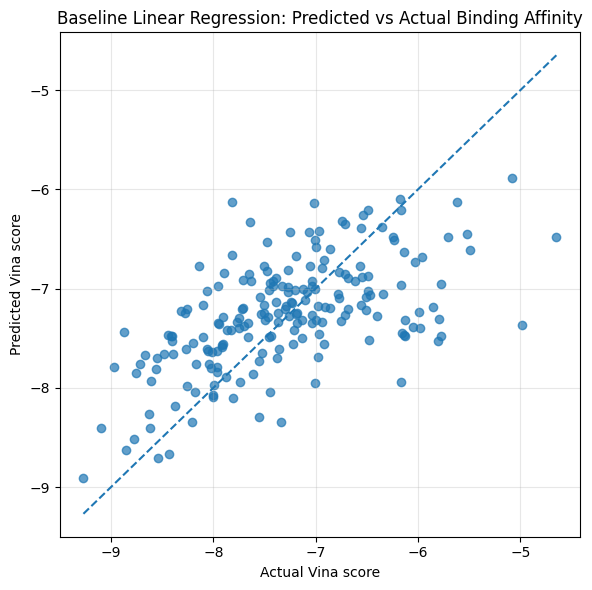

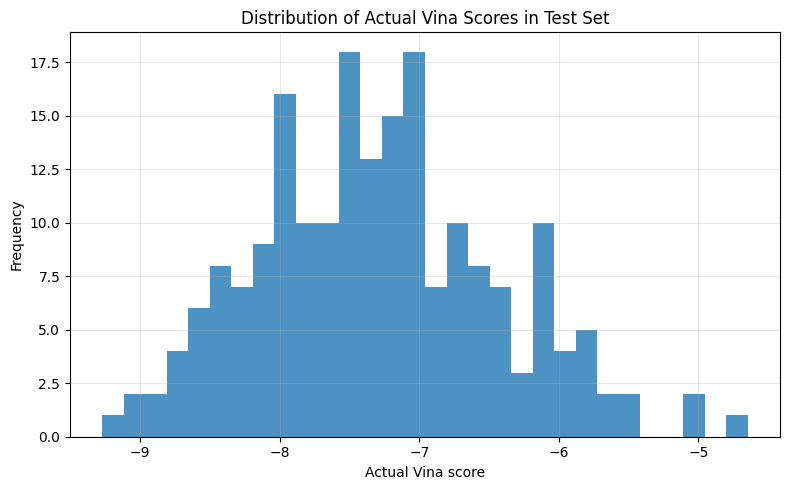

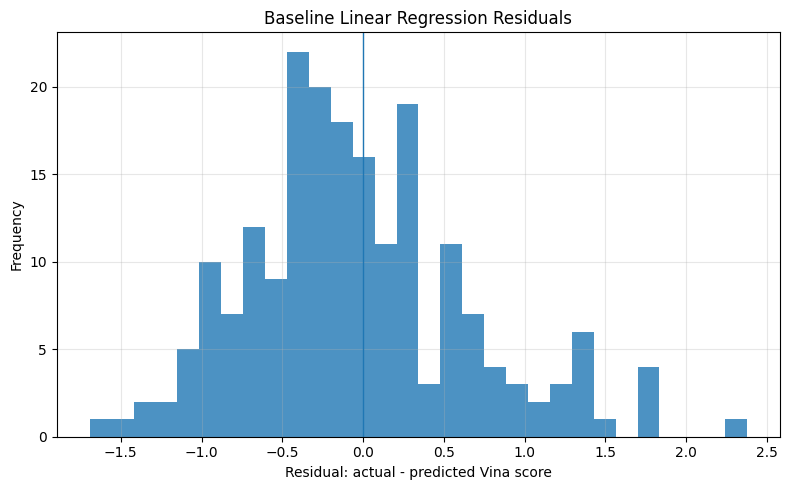

In [105]:
# Phase 7.C.2 — Baseline diagnostic plots

test_residuals = y_test - y_test_pred

# Predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Vina score")
plt.ylabel("Predicted Vina score")
plt.title("Baseline Linear Regression: Predicted vs Actual Binding Affinity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Distribution of actual binding affinity values in test set
plt.figure(figsize=(8, 5))
plt.hist(y_test, bins=30, alpha=0.8)
plt.xlabel("Actual Vina score")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Vina Scores in Test Set")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Residual histogram
plt.figure(figsize=(8, 5))
plt.hist(test_residuals, bins=30, alpha=0.8)
plt.axvline(0, linewidth=1)
plt.xlabel("Residual: actual - predicted Vina score")
plt.ylabel("Frequency")
plt.title("Baseline Linear Regression Residuals")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The baseline linear regression shows a moderate relationship between predicted and actual Vina scores, but the predicted values are compressed toward the middle of the binding-affinity range. In the predicted-vs-actual plot, the model tracks the general trend but underestimates the strongest binders with very negative Vina scores and overestimates/underestimates several weaker binders near the high end of the score range. The target distribution shows that most test-set Vina scores are concentrated around approximately -8 to -6.5, with fewer extreme values, which may partly explain why the model predicts toward the center. The residual histogram is roughly centered near zero but has noticeable spread and a right tail, suggesting that the baseline model is not strongly biased overall but still makes sizable errors for some molecules. Overall, this baseline provides a useful starting point, but regularization and feature-subset testing may improve stability and help determine whether a smaller set of descriptors can explain binding affinity more reliably.

In [103]:
# Phase 7.C.3 — Baseline feature coefficients

coef_df_baseline = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": linreg.coef_,
    "abs_coefficient": np.abs(linreg.coef_)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df_baseline)

,feature,coefficient,abs_coefficient
2,rings,-0.344094,0.344094
1,hba,0.302264,0.302264
3,aromatic_rings,-0.292040,0.292040
4,tpsa,-0.232349,0.232349
8,sim_r1_tv_frag,-0.097300,0.097300
0,hbd,0.073745,0.073745
5,logp,-0.065923,0.065923
6,mw,0.046503,0.046503
7,amide,0.030229,0.030229


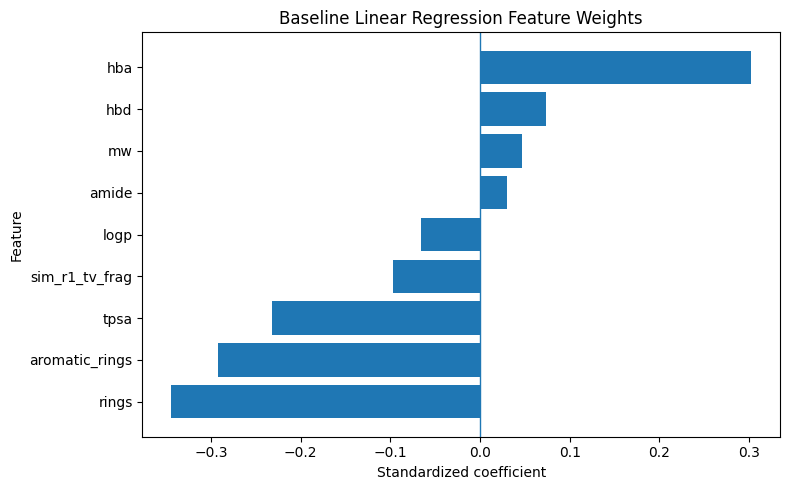

In [104]:
coef_plot_df = coef_df_baseline.sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(coef_plot_df["feature"], coef_plot_df["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("Baseline Linear Regression Feature Weights")
plt.tight_layout()
plt.show()

### Baseline Linear Regression Feature Weight Interpretation

The baseline linear regression coefficient plot suggests that chemical descriptor features have a stronger impact on predicted binding affinity than the structural similarity score. The largest positive coefficient is associated with **hydrogen bond acceptors**, while the largest negative coefficients are associated with total **ring count**, **aromatic rings**, and **TPSA**. Because the model was fit using standardized features, these coefficient magnitudes are directly comparable. It is somewhat surprising that the **similarity score** is not one of the dominant predictors, since the docked candidates were originally selected based on structural similarity to rapamycin. This suggests that the model may not simply be learning that “more similar molecules bind better,” but instead that specific molecular properties related to hydrogen bonding, ring structure, aromaticity, and polarity may better explain variation in predicted Vina binding scores.

In [106]:
# Phase 7.C.4 — Baseline error analysis by cluster and similarity quartile

baseline_eval_df = test_df.copy()

baseline_eval_df["y_true"] = y_test.values
baseline_eval_df["y_pred"] = y_test_pred
baseline_eval_df["residual"] = baseline_eval_df["y_true"] - baseline_eval_df["y_pred"]
baseline_eval_df["abs_error"] = baseline_eval_df["residual"].abs()
baseline_eval_df["squared_error"] = baseline_eval_df["residual"] ** 2

quartile_error_df = (
    baseline_eval_df
    .groupby(["cluster_k2", "quartile"])
    .agg(
        n=("vina_score", "size"),
        mean_actual_vina=("y_true", "mean"),
        mean_predicted_vina=("y_pred", "mean"),
        mean_residual=("residual", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean()))
    )
    .reset_index()
)

display(quartile_error_df)

,cluster_k2,quartile,n,mean_actual_vina,mean_predicted_vina,mean_residual,MAE,RMSE
0,0,3,30,-7.373267,-7.456714,0.083447,0.491288,0.631045
1,0,2,30,-7.519133,-7.503995,-0.015138,0.563735,0.706388
2,0,1,30,-7.174533,-7.109440,-0.065093,0.413531,0.569620
3,0,0,30,-7.231733,-7.200991,-0.030742,0.591468,0.724282
4,1,3,20,-7.500100,-7.284148,-0.215952,0.414477,0.503066
5,1,2,20,-7.353800,-7.188435,-0.165365,0.492105,0.635641
6,1,1,20,-7.359250,-7.132467,-0.226783,0.611741,0.703740
7,1,0,20,-6.819300,-7.088321,0.269021,0.828647,1.014204


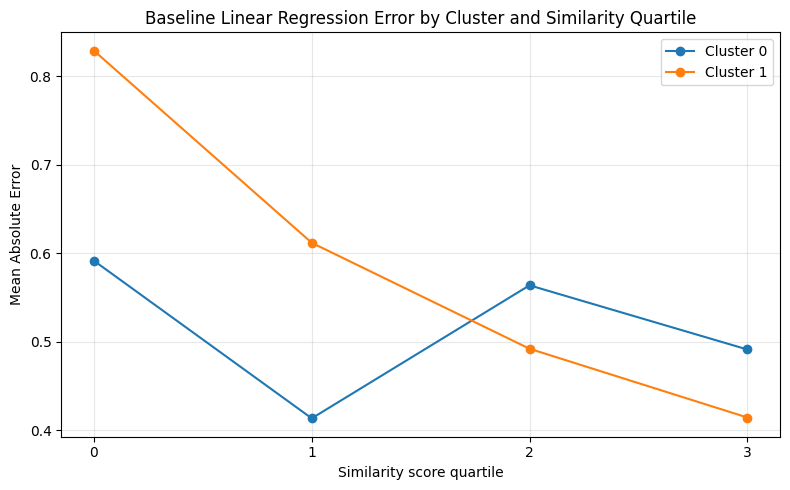

In [107]:
# Baseline MAE by cluster and similarity quartile

plt.figure(figsize=(8, 5))

for cluster_id in sorted(quartile_error_df["cluster_k2"].unique()):
    cluster_data = quartile_error_df[quartile_error_df["cluster_k2"] == cluster_id]
    plt.plot(
        cluster_data["quartile"],
        cluster_data["MAE"],
        marker="o",
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Similarity score quartile")
plt.ylabel("Mean Absolute Error")
plt.title("Baseline Linear Regression Error by Cluster and Similarity Quartile")
plt.xticks(sorted(quartile_error_df["quartile"].unique()))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

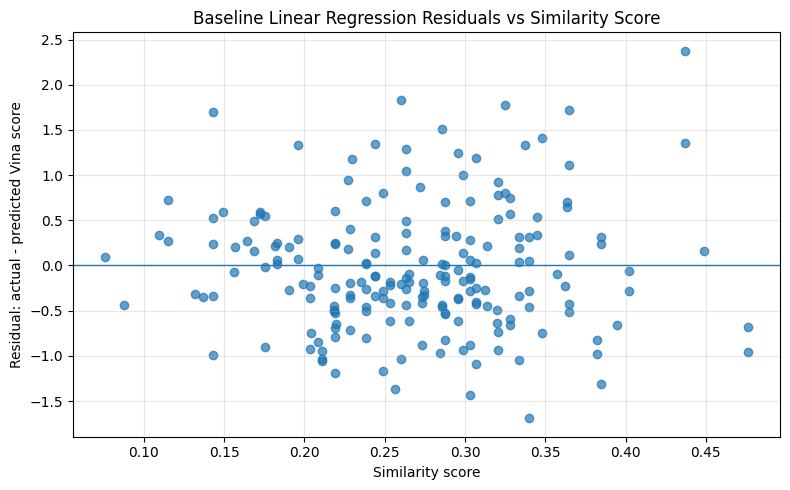

In [108]:
# Phase 7.C.5 — Residuals vs similarity score

plt.figure(figsize=(8, 5))
plt.scatter(
    baseline_eval_df["sim_r1_tv_frag"],
    baseline_eval_df["residual"],
    alpha=0.7
)

plt.axhline(0, linewidth=1)
plt.xlabel("Similarity score")
plt.ylabel("Residual: actual - predicted Vina score")
plt.title("Baseline Linear Regression Residuals vs Similarity Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The baseline error analysis shows that model performance is not perfectly uniform across the cluster/quartile sampling groups. Cluster 0 has relatively stable MAE values across quartiles, while Cluster 1 shows noticeably higher error in quartile 0, suggesting that the model may struggle more with the lowest-similarity molecules in that cluster. The residuals-vs-similarity plot does not show a strong linear trend between similarity score and residual size, but the residual spread remains fairly wide across the similarity range, with several larger positive and negative errors. This suggests that similarity score alone does not explain where the model performs well or poorly, which is consistent with the earlier coefficient plot where similarity score was not one of the dominant predictors. Overall, the baseline model appears useful as a starting point, but the uneven subgroup errors support trying regularized models and feature-subset comparisons next.

In [ ]:
# Phase 7.D.1 — Elastic Net cross-validation

from sklearn.linear_model import ElasticNetCV

# Test a range of regularization strengths
alphas = np.logspace(-4, 2, 50)

# Test different L1/L2 mixtures
# Higher l1_ratio = more Lasso-like
# Lower l1_ratio = more Ridge-like
l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

elastic = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=10000,
    n_jobs=-1,
    random_state=42
)

elastic.fit(X_train_scaled, y_train)

print(f"Best alpha:    {elastic.alpha_:.6f}")
print(f"Best l1_ratio: {elastic.l1_ratio_:.2f}")

Best alpha:    0.000100
Best l1_ratio: 0.10


In [110]:
# Phase 7.D.2 — Elastic Net metrics

y_train_pred_elastic = elastic.predict(X_train_scaled)
y_test_pred_elastic = elastic.predict(X_test_scaled)

elastic_r2_train = r2_score(y_train, y_train_pred_elastic)
elastic_r2_test = r2_score(y_test, y_test_pred_elastic)

elastic_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_elastic))
elastic_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_elastic))

elastic_mae_train = mean_absolute_error(y_train, y_train_pred_elastic)
elastic_mae_test = mean_absolute_error(y_test, y_test_pred_elastic)

print(f"Train R2:   {elastic_r2_train:.4f}")
print(f"Test R2:    {elastic_r2_test:.4f}")
print(f"Train RMSE: {elastic_rmse_train:.4f}")
print(f"Test RMSE:  {elastic_rmse_test:.4f}")
print(f"Train MAE:  {elastic_mae_train:.4f}")
print(f"Test MAE:   {elastic_mae_test:.4f}")

Train R2:   0.2928
Test R2:    0.3424
Train RMSE: 0.7931
Test RMSE:  0.6928
Train MAE:  0.6208
Test MAE:   0.5437


In [111]:
# Phase 7.D.3 — Elastic Net feature coefficients

coef_df_elastic = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": elastic.coef_,
    "abs_coefficient": np.abs(elastic.coef_)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df_elastic)

,feature,coefficient,abs_coefficient
2,rings,-0.344028,0.344028
1,hba,0.302079,0.302079
3,aromatic_rings,-0.291973,0.291973
4,tpsa,-0.232109,0.232109
8,sim_r1_tv_frag,-0.097242,0.097242
0,hbd,0.073642,0.073642
5,logp,-0.065918,0.065918
6,mw,0.046481,0.046481
7,amide,0.030115,0.030115


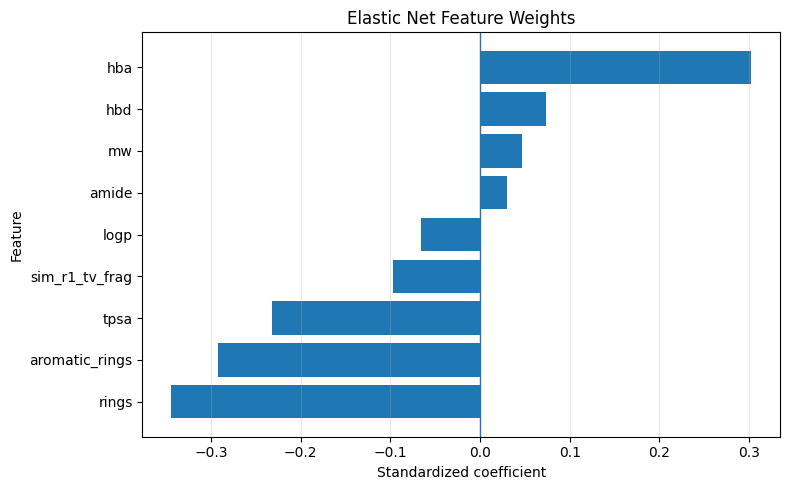

In [112]:
# Elastic Net feature weight plot

coef_plot_df = coef_df_elastic.sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(coef_plot_df["feature"], coef_plot_df["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("Elastic Net Feature Weights")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [113]:
# Phase 7.D.4 — Compare baseline Linear Regression vs Elastic Net

comparison_df = pd.DataFrame([
    {
        "model": "Baseline Linear Regression",
        "train_R2": r2_train,
        "test_R2": r2_test,
        "train_RMSE": rmse_train,
        "test_RMSE": rmse_test,
        "train_MAE": mae_train,
        "test_MAE": mae_test
    },
    {
        "model": "Elastic Net",
        "train_R2": elastic_r2_train,
        "test_R2": elastic_r2_test,
        "train_RMSE": elastic_rmse_train,
        "test_RMSE": elastic_rmse_test,
        "train_MAE": elastic_mae_train,
        "test_MAE": elastic_mae_test
    }
])

display(comparison_df)

,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Baseline Linear Regression,0.292831,0.342379,0.793074,0.692846,0.620836,0.543700
1,Elastic Net,0.292831,0.342407,0.793074,0.692831,0.620829,0.543685


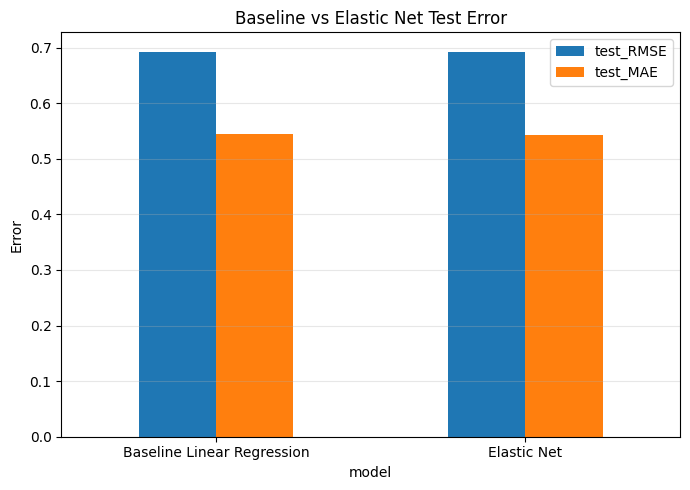

In [114]:
# Compare test errors

metric_plot_df = comparison_df[["model", "test_RMSE", "test_MAE"]].set_index("model")

metric_plot_df.plot(kind="bar", figsize=(7, 5))
plt.ylabel("Error")
plt.title("Baseline vs Elastic Net Test Error")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The Elastic Net model produced nearly identical performance to the baseline linear regression model. Test R2, RMSE, and MAE changed only minimally, and the feature-weight plot shows the same overall coefficient pattern: **hydrogen bond acceptors** have the largest positive coefficient, while **total rings**, **aromatic rings**, and **TPSA** have the largest negative coefficients. This suggests that Elastic Net regularization did not substantially improve generalization or change the model’s interpretation. One possible explanation is that the optimal regularization strength selected by cross-validation was weak, causing the Elastic Net model to behave very similarly to ordinary linear regression. Next, we compare pure L1 regularization using Lasso and pure L2 regularization using Ridge to test whether either feature selection or coefficient shrinkage provides a clearer improvement.

In [115]:
print(f"Best alpha:    {elastic.alpha_}")
print(f"Best l1_ratio: {elastic.l1_ratio_}")

Best alpha:    0.0001
Best l1_ratio: 0.1


The best Elastic Net model selected a low `l1_ratio` of 0.1, meaning the regularization penalty favored mostly L2/Ridge-like shrinkage rather than L1/Lasso-style feature selection. The selected `alpha` was also small, which helps explain why Elastic Net produced results nearly identical to the baseline linear regression model. Based on this result, Ridge regression is the more directly motivated next model to test. However, we also test Lasso as a pure L1 comparison to see whether forcing stronger feature selection changes model performance or interpretation.

In [ ]:
# Phase 7.E.1 — Ridge and Lasso cross-validation

from sklearn.linear_model import RidgeCV, LassoCV

alphas = np.logspace(-4, 2, 50)

# L2 Regularization - Ridge
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)

# L1 Regularization - Lasso
lasso = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42,
    n_jobs=-1
)
lasso.fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {ridge.alpha_:.6f}")
print(f"Best Lasso alpha: {lasso.alpha_:.6f}")

Best Ridge alpha: 100.000000
Best Lasso alpha: 0.000100


In [118]:
# Phase 7.E.2 — Ridge and Lasso metrics

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

ridge_r2_train = r2_score(y_train, y_train_pred_ridge)
ridge_r2_test = r2_score(y_test, y_test_pred_ridge)
ridge_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
ridge_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
ridge_mae_train = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_mae_test = mean_absolute_error(y_test, y_test_pred_ridge)

lasso_r2_train = r2_score(y_train, y_train_pred_lasso)
lasso_r2_test = r2_score(y_test, y_test_pred_lasso)
lasso_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
lasso_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
lasso_mae_train = mean_absolute_error(y_train, y_train_pred_lasso)
lasso_mae_test = mean_absolute_error(y_test, y_test_pred_lasso)

print("Ridge Regression Metrics:")
print(f"Train R2:   {ridge_r2_train:.4f}")
print(f"Test R2:    {ridge_r2_test:.4f}")
print(f"Train RMSE: {ridge_rmse_train:.4f}")
print(f"Test RMSE:  {ridge_rmse_test:.4f}")
print(f"Train MAE:  {ridge_mae_train:.4f}")
print(f"Test MAE:   {ridge_mae_test:.4f}")

print("\nLasso Regression Metrics:")
print(f"Train R2:   {lasso_r2_train:.4f}")
print(f"Test R2:    {lasso_r2_test:.4f}")
print(f"Train RMSE: {lasso_rmse_train:.4f}")
print(f"Test RMSE:  {lasso_rmse_test:.4f}")
print(f"Train MAE:  {lasso_mae_train:.4f}")
print(f"Test MAE:   {lasso_mae_test:.4f}")

Ridge Regression Metrics:
Train R2:   0.2839
Test R2:    0.3476
Train RMSE: 0.7981
Test RMSE:  0.6901
Train MAE:  0.6230
Test MAE:   0.5406

Lasso Regression Metrics:
Train R2:   0.2928
Test R2:    0.3425
Train RMSE: 0.7931
Test RMSE:  0.6928
Train MAE:  0.6208
Test MAE:   0.5436


In [119]:
# Phase 7.E.3 — Compare all linear and regularized models

comparison_df = pd.DataFrame([
    {
        "model": "Baseline Linear Regression",
        "train_R2": r2_train,
        "test_R2": r2_test,
        "train_RMSE": rmse_train,
        "test_RMSE": rmse_test,
        "train_MAE": mae_train,
        "test_MAE": mae_test
    },
    {
        "model": "Elastic Net",
        "train_R2": elastic_r2_train,
        "test_R2": elastic_r2_test,
        "train_RMSE": elastic_rmse_train,
        "test_RMSE": elastic_rmse_test,
        "train_MAE": elastic_mae_train,
        "test_MAE": elastic_mae_test
    },
    {
        "model": "Ridge",
        "train_R2": ridge_r2_train,
        "test_R2": ridge_r2_test,
        "train_RMSE": ridge_rmse_train,
        "test_RMSE": ridge_rmse_test,
        "train_MAE": ridge_mae_train,
        "test_MAE": ridge_mae_test
    },
    {
        "model": "Lasso",
        "train_R2": lasso_r2_train,
        "test_R2": lasso_r2_test,
        "train_RMSE": lasso_rmse_train,
        "test_RMSE": lasso_rmse_test,
        "train_MAE": lasso_mae_train,
        "test_MAE": lasso_mae_test
    }
])

display(comparison_df)

,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Baseline Linear Regression,0.292831,0.342379,0.793074,0.692846,0.620836,0.543700
1,Elastic Net,0.292831,0.342407,0.793074,0.692831,0.620829,0.543685
2,Ridge,0.283915,0.347592,0.798058,0.690094,0.623017,0.540601
3,Lasso,0.292830,0.342454,0.793075,0.692806,0.620812,0.543641


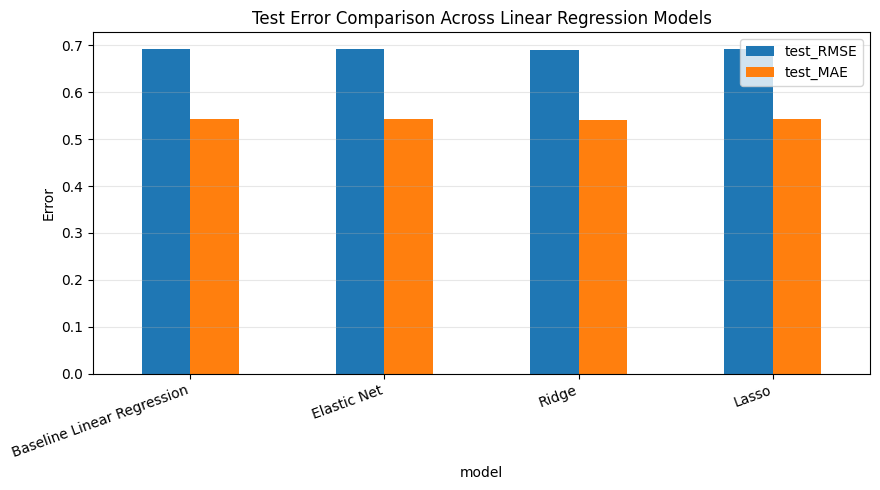

In [120]:
# Test error comparison plot

metric_plot_df = comparison_df[["model", "test_RMSE", "test_MAE"]].set_index("model")

metric_plot_df.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Error")
plt.title("Test Error Comparison Across Linear Regression Models")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [121]:
# Phase 7.E.4 — Coefficient comparison across models

coef_compare_df = pd.DataFrame({
    "feature": X_train.columns,
    "baseline": linreg.coef_,
    "elastic_net": elastic.coef_,
    "ridge": ridge.coef_,
    "lasso": lasso.coef_
})

display(coef_compare_df)

,feature,baseline,elastic_net,ridge,lasso
0,hbd,0.073745,0.073642,0.030085,0.073359
1,hba,0.302264,0.302079,0.201088,0.301737
2,rings,-0.344094,-0.344028,-0.295298,-0.343867
3,aromatic_rings,-0.292040,-0.291973,-0.244553,-0.291822
4,tpsa,-0.232349,-0.232109,-0.111956,-0.231486
5,logp,-0.065923,-0.065918,-0.066383,-0.065801
6,mw,0.046503,0.046481,0.036292,0.046281
7,amide,0.030229,0.030115,-0.026410,0.029845
8,sim_r1_tv_frag,-0.097300,-0.097242,-0.062787,-0.097015


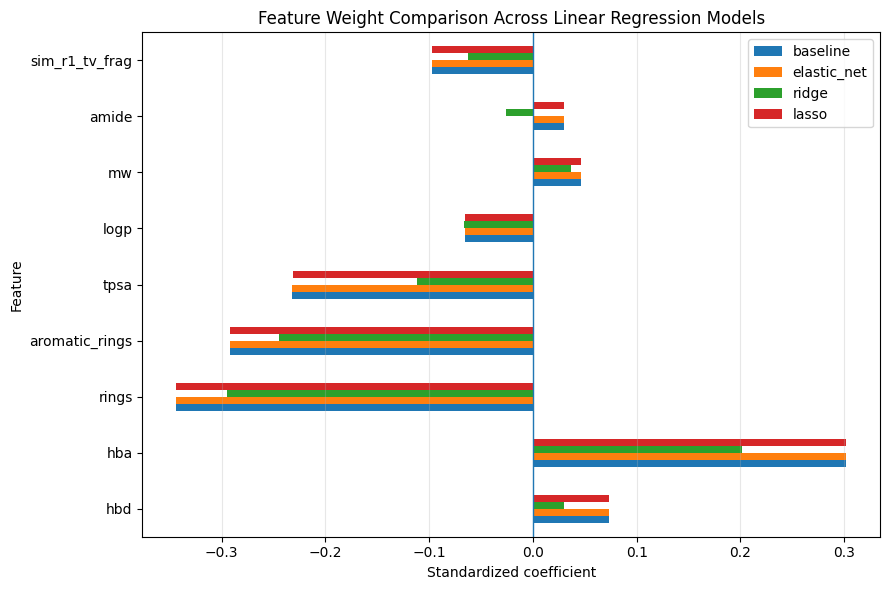

In [122]:
# Coefficient comparison plot

coef_compare_plot_df = coef_compare_df.set_index("feature")

coef_compare_plot_df.plot(kind="barh", figsize=(9, 6))
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("Feature Weight Comparison Across Linear Regression Models")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Across the baseline linear regression, Elastic Net, Ridge, and Lasso models, performance was very similar. Ridge produced the lowest test RMSE and MAE and the highest test R2, but the improvement over the baseline model was very small. This suggests that regularization did not substantially improve predictive performance for this feature set, although Ridge’s slightly better test metrics are consistent with the Elastic Net result, which favored a mostly L2/Ridge-like penalty. The coefficient comparison also shows that the same features remain influential across models: **hydrogen bond acceptors** have the strongest positive coefficient, while **total rings**, **aromatic rings**, and **TPSA** have the strongest negative coefficients. Lasso did not remove any features entirely, so the model does not clearly reduce to a smaller sparse feature set. Overall, the regularized models support the same interpretation as the baseline model: binding affinity is partly explained by chemical descriptors related to hydrogen bonding, ring structure, aromaticity, and polarity, while **similarity score** remains a secondary predictor rather than the dominant driver.